# <center> **Multi-Agent Reinforcement Learning for Grid Transportation Task**</center>
---

## **Task Analysis**

### **Task Details**

#### 1.**Envrionment**: 
- a $5 \times 5$ grid world
- Sending cell A
- Receiving cell B

#### 2.**Task**: 
- Transport items continuously from A to B
- Avoid **head-on collisions** which happens between different carrying state agents in same cell except A and B during transportation

#### 3.**Agent**:
- There are four agents in this envrionment doing the task
- All agents perform their actions sequentially in a random order
- Each agent can only transport 1 item at the same time
- Agents are born randomly at A or B

### **Task Requirements**
- Use **tabular-q** or **DQN (deep q-network)** or any other q-learning based algorithms to solve this task.
- Training must be done within:
    1. 1,500,000 agent-steps 
    2. 10 minutes 
    3. 4000 collisions
- After training, the agents must be able to perform a single delivery (starting at B) in at least 75% of all scenarios within at most 25 steps collision-free.

### **Performance Bonus**
The assignment offers performance bonuses that can offset the cost of purchased options:

| Performance Level | Scenarios Solved | Collisions During Training | Performance Points |
|-------------------|------------------|-----------------------------|-------------------|
| High              | >95%             | <500                        | 2                 |
| Medium            | >85%             | <1,000                      | 1                 |
| Minimum           | >75%             | <4,000                      | 0                 |

### **Purchasable Options**

The assignment offers various options to simplify the task at the cost of points. These "purchasable" options create an interesting trade-off - simplifying the learning problem might enable higher performance, potentially offsetting the points spent.

#### Sensor Options
| Option | Description | Cost |
|--------|-------------|------|
| State of neighboring cells | Augment observation with occupancy state of cells in agent's 8-neighborhood | 2 |
| State of neighboring cells with agent type checking | Only mark cells with agents going in opposite direction as occupied | 3 |

These options improve agents' ability to detect and avoid potential collisions by enhancing their perception.

#### Coordination Options
| Option | Description | Cost |
|--------|-------------|------|
| Central clock | Coordinate agent update schedule (e.g., round-robin) instead of random order | 1 |

This option reduces the non-stationarity of the environment by making agent turns more predictable.

#### Training Condition Options
| Option | Description | Cost |
|--------|-------------|------|
| Off-the-job training | Define training episode start configurations rather than using random initialization | 2 |
| Staged Training | Break training into phases with different parameters, passing Q-tables/networks between stages | 3 |

These options allow for more controlled, curriculum-based learning approaches.

#### Setup Options
| Option | Description | Cost |
|--------|-------------|------|
| Fixed delivery location B | B is always in the bottom right corner (but agents cannot observe it directly) | 4 |

This option significantly reduces the state space but removes agents' ability to observe point B.

### Strategic Considerations

The assignment design creates interesting trade-offs between:

1. **Simplicity vs. Performance**: Purchasing options simplifies the problem but reduces potential grades
2. **Exploration vs. Cost**: Early purchase decisions must be made before knowing which options are most effective
3. **Resource Allocation**: Limited computing resources must be allocated between exploration, exploitation, and evaluation

Our implementation will need to carefully consider these trade-offs to maximize performance within the constraints.

## **Strategic Analysis of Selected Purchasable Options**

### Options Selected

1. **State of neighboring cells with agent type checking** (3 points)
2. **Central clock** (1 point)

Total cost: 4 points

### Detailed Justification

#### Option 1: State of neighboring cells with agent type checking (3 points)

##### What this option provides:
This option enhances the agent's observation space by providing information about adjacent cells that contain agents moving in the opposite direction (i.e., potential collision risks).

##### Strategic value:

1. **Improved Collision Prediction**
   - The fundamental challenge in this environment is avoiding head-on collisions between agents moving in opposite directions
   - Without this sensor enhancement, agents can only react to collisions after they occur
   - With this enhancement, agents can anticipate potential collisions before they happen
   - This transforms the problem from reactive to proactive collision avoidance

2. **Reduced State Space Ambiguity**
   - In the base environment, the agent has insufficient information to distinguish between safe and dangerous situations
   - A position that appears identical could be safe in one instance and dangerous in another
   - This option reduces this ambiguity by providing critical information about the most relevant environmental factor (opposing agents)
   - The agent can now learn different policies for otherwise identical-looking states

3. **Improved Signal-to-Noise Ratio**
   - By only flagging cells occupied by agents moving in the opposite direction (not all agents)
   - The observation contains exactly the information needed for collision avoidance
   - This targeted sensor design eliminates irrelevant information that could slow learning

4. **Quantifiable Value for Learning**
   - Reduces exploration needed to develop effective collision avoidance strategies
   - Enables more direct credit assignment for successful avoidance actions
   - Creates clearer correlations between observations and optimal actions

#### Option 2: Central clock (1 point)

##### What this option provides:
This option changes the action selection mechanism from random agent ordering to a fixed, predictable sequence.

##### Strategic value:

1. **Reduced Environment Stochasticity**
   - The base environment has random agent ordering, introducing unnecessary randomness
   - Fixed agent ordering makes the environment more deterministic
   - Deterministic environments are typically easier for reinforcement learning algorithms to master
   - This creates a more stable learning environment for all agents

2. **Exceptional Value Proposition**
   - At only 1 point, this is the least expensive option available
   - Yet it addresses a fundamental source of complexity in multi-agent learning
   - Offers disproportionate benefit relative to its cost
   - Functions as a "force multiplier" for other options

3. **Improved Policy Consistency**
   - With random agent ordering, the same state might require different actions depending on unknown future agent actions
   - Fixed ordering allows agents to learn more consistent action-value mappings
   - Removes a source of apparent non-stationarity in the environment

4. **Coordination Benefits**
   - Enables emergent coordination patterns between agents
   - Agents can learn to leverage the predictable action sequence
   - Creates implicit turn-taking behavior, reducing accidental collisions

### Expected Performance Improvements

#### Learning Efficiency

1. **Faster Convergence**
   - The selected options significantly reduce the effective complexity of the learning problem
   - Agents should require fewer training episodes to reach performance thresholds
   - The learning curve should show more consistent improvement with fewer plateaus

2. **Lower Collision Rate During Training**
   - Adjacent cell sensing enables preemptive collision avoidance
   - The reduction in collisions compounds over time as less negative feedback occurs
   - This may qualify for performance bonuses (fewer than 500-1000 collisions during training)

3. **More Effective Exploration**
   - Enhanced observations allow more targeted exploration of relevant state-action pairs
   - The Q-table will focus on important state distinctions rather than irrelevant variations
   - More efficient use of the exploration budget (epsilon decay schedule)

#### Solution Quality

1. **Higher Success Rate**
   - The enhanced state representation allows for more nuanced policies
   - Agents can learn specialized behaviors for different traffic patterns
   - This should achieve the 95%+ success rate threshold for maximum performance points

2. **Shorter Path Lengths**
   - Better collision avoidance means fewer deviations from optimal paths
   - Agents can learn to coordinate path selection more efficiently
   - Improved average steps to completion metric

3. **Robustness to Different Scenarios**
   - The solution should generalize better to varied A-B configurations
   - Performance should be more consistent across the test suite

### Cost-Benefit Analysis

The total cost of 4 points represents a strategic investment that balances capability enhancement with cost efficiency:

1. These options directly address the two most significant sources of difficulty in the problem:
   - Limited perception (addressed by adjacent cell sensing)
   - Environment unpredictability (addressed by central clock)

2. The combination creates synergistic benefits:
   - Predictable agent ordering enhances the value of adjacent cell information
   - Together they transform a partially observable, stochastic problem into a more manageable learning task

3. Performance bonuses achievable with these enhancements could potentially offset their cost:
   - 1 point for >85% success rate with <1,000 collisions
   - 2 points for >95% success rate with <500 collisions

Through this strategic selection, the implementation can achieve superior performance while maintaining a reasonable point budget, maximizing the final evaluation score.


## Implementation Approach

### 1. Problem Decomposition

I approached the non-episodic transportation challenge by decomposing it into repeating episodic patterns. Rather than treating the continuous A→B→A→B shuttling as a single task, I redefined it as discrete episodes of navigation from a current position to a destination. This transformation aligned with the Markovian assumption of reinforcement learning, where action selection depends only on the current state rather than the history of actions.

The key insight was recognizing the symmetrical nature of the A→B and B→A journeys. By exploiting this symmetry, I could simplify both the state representation and the learning process, effectively converting an infinite-horizon problem into a collection of finite, episodic tasks.

### 2. State Representation Optimization

I developed a minimalist state representation that eliminated redundant information while preserving the essential features needed for effective navigation and coordination:

1. **Position-Based State**: The agent's current position coordinates formed the core of the state representation.

2. **Destination-Only Approach**: Rather than explicitly including both the starting point and carrying state, I observed that these could be implicitly represented through the destination. If the destination is B, the agent must be carrying an item; if the destination is A, it must not be carrying.

3. **Adjacency Information**: The state included data about adjacent cells occupied by agents moving in the opposite direction, which was critical for collision avoidance.

This streamlined representation reduced the state space dimensionality significantly while maintaining all information necessary for effective policy learning.

### 3. Agent Specialization

I simplified the multi-agent dynamics by categorizing agents into just two types:

1. Agents with destination A (returning without items)
2. Agents with destination B (carrying items for delivery)

This classification allowed me to configure the training environment with just two opposing agents, significantly reducing the complexity of the learning problem while still capturing the essential coordination challenge. The learned policies could then be applied to scenarios with more agents.

### 4. Collision Avoidance Mechanisms

To address the central challenge of collision avoidance, I implemented several complementary mechanisms:

1. **Directional Adjacency Sensing**: I purchased the option for agents to detect opposite-type agents in adjacent cells, focusing on the four cardinal directions (N, S, E, W) rather than all eight surrounding cells. This simplification was valid because corner conflicts would manifest as cardinal adjacencies after agents moved.

2. **Collision State Representation**: I discovered that when collisions occurred, the adjacency sensors would reset to [0,0,0,0] since the opposing agent was now in the same cell rather than adjacent. This created ambiguity in the state representation. To resolve this, I set the sensors to [1,1,1,1] when collisions occurred, effectively signaling an "unavoidable collision" state. This critical modification helped separate collision states from empty-adjacency states in the Q-table.

3. **Penalty Structure**: Agents received penalties proportional to the number of adjacent cells occupied by opposite-moving agents, creating a gradient that encouraged collision avoidance.

### 5. Training Optimizations

I implemented several optimizations to accelerate and improve the training process:

1. **Episode Termination**: Agents were marked as "done" upon reaching their destinations, preventing wasted training iterations on already-optimal behaviors and focusing computational resources on situations requiring learning.

2. **Dynamic Episode Length**: Rather than using a fixed number of steps per episode, I defined the maximum steps as 30 times the Manhattan distance between A and B. This ensured fair resource allocation across different environment configurations.

3. **Heuristic Rewards**: Instead of uniform step penalties, I implemented distance-based rewards proportional to the Manhattan distance to the destination. This encouraged agents to find efficient paths rather than taking unnecessary detours.

4. **Action Masking**: I restricted the action space to legal moves only, eliminating the need for wall collision penalties and reducing the effective action space, which accelerated learning.

5. **Symmetrical Training**: By treating pickup and dropoff actions as functionally identical operations (just at different locations), I leveraged the inherent symmetry of the task to enable faster generalization.

Through this combination of problem decomposition, representation optimization, and targeted learning enhancements, agents successfully learned to navigate efficiently while avoiding collisions, achieving the coordination objective with minimal training resources.

## **Model the environment**
With information above, try to model the envirionment.

### **External Package**
To model the environment efficiently, package **PettingZoo** is used here. Its **AECEnv** (Agent Environment Cycle Environment) perfectly suits the requirement that all agents act sequentially in random order.

In [70]:
import random
import numpy as np
from pettingzoo import AECEnv
from pettingzoo.utils import AgentSelector
from scipy.spatial import distance

# === Environment Configuration Constants ===
GRID_SIZE = 5  # Size of the square grid (5x5)
NUM_AGENTS = 4  # Number of agents in the environment

# === Reward Structure Constants ===
REWARD_COLLISION = -100  # Large negative reward for head-on collisions
REWARD_TASK_COMPLETION = 100  # Reward for completing the task (pickup and dropoff)
REWARD_STEP = -1  # Small negative reward for each step
REWARD_ADJACENT_OCCUPANCY = -20  # Penalty for potential collision risk

# Environment modes
MODE_NORMAL = 0  # Regular mode with all agents
MODE_TRAINING = 1  # Training mode with termination on completion
MODE_TESTING = 2  # Testing mode for final evaluation

# Movement directions: (row_delta, col_delta)
ACTIONS = {
    0: (-1, 0),  # North (decrease row)
    1: (1, 0),  # South (increase row)
    2: (0, 1),  # East (increase column)
    3: (0, -1),  # West (decrease column)
}


class env(AECEnv):
    """
    Multi-agent gridworld environment for the transportation task.
    """

    metadata = {"render_modes": ["human"], "name": "transport_task_v1"}

    def __init__(self):
        """Initialize the environment with default settings."""
        super().__init__()
        self.possible_agents = [f"agent_{i}" for i in range(NUM_AGENTS)]
        self.actions = ACTIONS

    def reset(self, seed=None, options=None):
        """Reset the environment to an initial state."""
        # Set random seed if provided
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Get mode from options
        self.mode = options.get("mode", MODE_NORMAL) if options else MODE_NORMAL

        # Reset agent positions and carrying states
        self._agent_positions = {}
        self._agent_is_carrying = {}

        # Set positions for A and B
        if options and "A_position" in options and "B_position" in options:
            self.position_A = options["A_position"]
            self.position_B = options["B_position"]
        else:
            # Randomly place A and B
            all_positions = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]
            self.position_A, self.position_B = random.sample(all_positions, 2)

        # Configure agents based on mode
        if self.mode == MODE_NORMAL:
            # Use all agents in normal mode
            self.agents = self.possible_agents.copy()
            self._agent_positions = {
                agent: random.choice([self.position_A, self.position_B])
                for agent in self.agents
            }
        elif self.mode == MODE_TRAINING:
            # For training, use only 2 agents with opposite goals
            self.agents = self.possible_agents[:2]
            # Place first agent at A and second agent at B
            self._agent_positions = {
                self.agents[0]: self.position_A,
                self.agents[1]: self.position_B,
            }
        elif self.mode == MODE_TESTING:
            # For testing, use all agents but place them strategically
            self.agents = self.possible_agents.copy()
            num_B_agents = options.get("num_B_agents", 2)
            self._agent_positions = {
                agent: self.position_B if i < num_B_agents else self.position_A
                for i, agent in enumerate(self.agents)
            }

        # Initialize carrying state based on position
        self._agent_is_carrying = {
            agent: pos == self.position_A
            for agent, pos in self._agent_positions.items()
        }

        # Reset counters and metrics
        self.collisions = 0
        self.completions = 0
        self.steps = 0

        # Initialize rewards and termination flags
        self._cumulative_rewards = {agent: 0 for agent in self.agents}
        self.rewards = {agent: 0 for agent in self.agents}
        self.terminations = {agent: False for agent in self.agents}
        self.truncations = {agent: False for agent in self.agents}

        # Initialize action masks
        self.infos = {
            agent: {"action_mask": self._calculate_action_mask(agent)}
            for agent in self.agents
        }

        # Configure agent selection
        self._agent_selector = AgentSelector(self.agents)
        self.agent_selection = self._agent_selector.next()

        # Return observation for the first agent
        return self.observe(self.agent_selection)

    def _calculate_action_mask(self, agent):
        """Calculate valid actions for an agent."""
        # Get agent's current position
        row, col = self._agent_positions[agent]

        # Default: all actions allowed
        action_mask = np.ones(4, dtype=int)

        # Check grid boundaries
        if row == 0:  # Top row - can't go North
            action_mask[0] = 0
        if row == GRID_SIZE - 1:  # Bottom row - can't go South
            action_mask[1] = 0
        if col == GRID_SIZE - 1:  # Rightmost column - can't go East
            action_mask[2] = 0
        if col == 0:  # Leftmost column - can't go West
            action_mask[3] = 0

        return action_mask

    def _get_adjacent_occupancies(self):
        """Get occupancy status of adjacent cells for collision risk."""
        # Initialize occupancies array
        occupancies = np.zeros(4, dtype=int)

        # Get current agent info
        agent = self.agent_selection
        row, col = self._agent_positions[agent]
        current_carrying = self._agent_is_carrying[agent]

        # Define adjacent cells
        adjacent_cells = [
            (row - 1, col),  # North
            (row + 1, col),  # South
            (row, col + 1),  # East
            (row, col - 1),  # West
        ]

        # Check if current position is already in a collision state
        if self._check_head_on_collision():
            return np.ones(4, dtype=int)  # All directions high risk

        # Check each adjacent cell
        for i, (adj_row, adj_col) in enumerate(adjacent_cells):
            # Skip if outside grid
            if not (0 <= adj_row < GRID_SIZE and 0 <= adj_col < GRID_SIZE):
                continue

            adj_pos = (adj_row, adj_col)

            # Skip cells A and B (no collisions there)
            if adj_pos in (self.position_A, self.position_B):
                continue

            # Check for agents with opposite carrying state (collision risk)
            for other_agent, other_pos in self._agent_positions.items():
                if (
                    other_agent != agent
                    and other_pos == adj_pos
                    and self._agent_is_carrying[other_agent] != current_carrying
                ):
                    # Found agent moving in opposite direction - mark as occupied
                    occupancies[i] = 1
                    break

        return occupancies

    def _check_head_on_collision(self):
        """Check if current agent has a head-on collision."""
        agent = self.agent_selection
        position = self._agent_positions[agent]

        # Only check for collisions if not at A or B
        if position in (self.position_A, self.position_B):
            return False

        carrying_state = self._agent_is_carrying[agent]

        # Check for other agents at same position with opposite carrying state
        for other_agent, other_pos in self._agent_positions.items():
            if (
                other_agent != agent
                and other_pos == position
                and self._agent_is_carrying[other_agent] != carrying_state
            ):
                return True

        return False

    def step(self, action):
        """Execute an action for the current agent and update the environment."""
        # Handle case where agent is already terminated
        if (
            self.terminations[self.agent_selection]
            or self.truncations[self.agent_selection]
        ):
            self._was_dead_step(action)
            return

        # Get current agent
        agent = self.agent_selection
        reward = 0
        current_position = self._agent_positions[agent]

        # Reset cumulative rewards for the current step
        self._cumulative_rewards[agent] = 0

        # Process action if provided
        if action is not None:
            # Calculate new position
            delta_row, delta_col = self.actions[action]
            new_row = current_position[0] + delta_row
            new_col = current_position[1] + delta_col
            new_position = (new_row, new_col)

            # Update agent position
            self._agent_positions[agent] = new_position

            # Calculate reward components
            # Distance-based reward
            destination = (
                self.position_B if self._agent_is_carrying[agent] else self.position_A
            )
            distance_to_goal = distance.cityblock(new_position, destination)
            reward += distance_to_goal * REWARD_STEP

            # Adjacent occupancy penalties
            occupancies = self._get_adjacent_occupancies()
            reward += np.sum(occupancies) * REWARD_ADJACENT_OCCUPANCY

            # Update action mask
            self.infos[agent]["action_mask"] = self._calculate_action_mask(agent)

            # Check for head-on collision
            if self._check_head_on_collision():
                reward += REWARD_COLLISION
                self.collisions += 1

            # Check for task completion
            if new_position == destination:
                # Toggle carrying state
                self._agent_is_carrying[agent] = not self._agent_is_carrying[agent]
                reward += REWARD_TASK_COMPLETION
                self.completions += 1

                # Mark agent as done in training mode
                if self.mode == MODE_TRAINING:
                    self.terminations[agent] = True

        # Update rewards
        self.rewards[agent] = reward
        self._accumulate_rewards()

        # Increment step counter
        self.steps += 1

        # Select next agent
        self.agent_selection = self._agent_selector.next()

    def observe(self, agent):
        """Return observation for the specified agent."""
        position = self._agent_positions[agent]

        # Basic observation
        observation = {
            "position": position,
            "position_A": self.position_A,
            "position_B": self.position_B,
            "is_carrying": self._agent_is_carrying[agent],
            "adjacent_occupancies": self._get_adjacent_occupancies(),
        }
        return observation

## **Implementing Learning**
To solve this task, try both tabular-q and DQN.
### **State Definition**
We can not directly use observation as state in our learning algorithm for it contains unrelated/indirect information.

Both q-learning and dqn are based Markov Process which is a stochastic process describing a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. 

In this task, 
- the agent's position is necessary for all steps of learning.
- carry state also changes with agents actions, but it's not direct information

For more efficient learning, we replace position_A, position_B, is_carrying in observation to **destination**.

Destination is A when agent is not carrying otherwise B.


## **Plotter**

### Training Visualization System

Our custom plotting system tracks agent learning progression and visualizes key performance metrics throughout training, providing comprehensive insights into agent behavior.

#### Key Metrics Tracked

- **Rewards**: Per-episode values showing learning progress
- **Steps**: Actions per episode, indicating path efficiency
- **Collisions**: Safety-critical collision frequency
- **Completions**: Successful deliveries per episode
- **Epsilon**: Exploration-exploitation balance over time
- **Algorithm-specific metrics**: Q-table size (Tabular) or Loss values (DQN)

#### Visualization Capabilities

The system generates a six-panel dashboard with moving averages to identify trends, marked stopping points for significant events, and visual indicators for different event types. This approach enables effective algorithm comparison and identifies specific strengths and weaknesses of each method.


In [71]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # Optional: for higher quality plots

In [72]:
# Use just one method to set the backend - at the top of your notebook
%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # Optional: for higher quality plots

import matplotlib.pyplot as plt
import numpy as np
import os
import time
from IPython.display import display

class TrainingPlotter:
    """
    Plotter for visualizing training metrics after agent training is complete.
    Displays plots inline in Jupyter notebooks.
    """

    def __init__(self, agent_type="tabular", figsize=(14, 9)):
        """Initialize the plotter."""
        self.agent_type = agent_type
        self.figsize = figsize

        # Initialize data storage
        self.episodes = []
        self.rewards = []
        self.steps = []
        self.collisions = []
        self.completions = []
        self.epsilons = []

        # Agent-specific metrics
        if agent_type == "tabular":
            self.q_table_sizes = []
        elif agent_type == "dqn":
            self.losses = []

        # Figure and axes will be created when needed
        self.fig = None
        self.axes = None
        self.stopping_points = []

        # Ensure plots directory exists
        os.makedirs("plots", exist_ok=True)

    def update(
        self,
        episode,
        reward=None,
        steps=None,
        collisions=None,
        completions=None,
        q_table_size=None,
        loss=None,
        epsilon=None,
    ):
        """Collect new metrics data during training."""
        # Append data to histories
        self.episodes.append(episode)

        if reward is not None:
            self.rewards.append(reward)

        if steps is not None:
            self.steps.append(steps)

        if collisions is not None:
            self.collisions.append(collisions)

        if completions is not None:
            self.completions.append(completions)

        if epsilon is not None:
            self.epsilons.append(epsilon)

        # Agent-specific metrics
        if self.agent_type == "tabular" and q_table_size is not None:
            self.q_table_sizes.append(q_table_size)

        elif self.agent_type == "dqn" and loss is not None:
            # Handle NaN values
            if np.isnan(loss):
                loss = self.losses[-1] if self.losses else 0
            self.losses.append(loss)

    def add_stopping_point(self, episode, reason):
        """Add a stopping point to mark important events during training."""
        self.stopping_points.append((episode, reason))

    def _create_plot(self):
        """Create a new figure and draw the final plot with all collected data."""
        # Make sure to fully close previous figures to avoid memory leaks
        if self.fig is not None:
            plt.close(self.fig)
        plt.close("all")  # Extra safety to ensure all figures are closed
        
        # Create with more moderate DPI to reduce memory usage
        self.fig, self.axes = plt.subplots(2, 3, figsize=self.figsize, dpi=100)
        self.axes = self.axes.flatten()

        # Configure subplot titles and labels
        plot_configs = [
            {
                "ax": self.axes[0],
                "title": "Reward per Episode",
                "y_label": "Reward",
                "data": self.rewards,
            },
            {
                "ax": self.axes[1],
                "title": "Steps per Episode",
                "y_label": "Steps",
                "data": self.steps,
            },
            {
                "ax": self.axes[2],
                "title": "Collisions per Episode",
                "y_label": "Collisions",
                "data": self.collisions,
                "min_val": 0,
            },
            {
                "ax": self.axes[3],
                "title": "Task Completions per Episode",
                "y_label": "Completions",
                "data": self.completions,
                "min_val": 0,
            },
            {
                "ax": self.axes[4],
                "title": "Exploration Rate (Epsilon)",
                "y_label": "Epsilon",
                "data": self.epsilons,
                "min_val": 0,
                "max_val": 1,
            },
        ]

        # Set up specific plot for agent type
        if self.agent_type == "tabular":
            plot_configs.append(
                {
                    "ax": self.axes[5],
                    "title": "Q-Table Size",
                    "y_label": "Number of States",
                    "data": self.q_table_sizes,
                    "min_val": 0,
                }
            )
        else:  # DQN
            plot_configs.append(
                {
                    "ax": self.axes[5],
                    "title": "Loss",
                    "y_label": "Loss Value",
                    "data": self.losses,
                    "min_val": 0,
                }
            )

        # Set font sizes
        fontsize_title = 12
        fontsize_labels = 11

        # Create numpy array for episodes
        episodes_array = np.array(self.episodes)

        # Plot each metric
        for config in plot_configs:
            ax = config["ax"]
            data = config["data"]

            # Set titles and labels
            ax.set_title(config["title"], fontsize=fontsize_title)
            ax.set_xlabel("Episode", fontsize=fontsize_labels)
            ax.set_ylabel(config["y_label"], fontsize=fontsize_labels)

            # Skip if no data
            if not data:
                continue

            # Create data array and plot
            data_array = np.array(data)

            # Handle special case for DQN loss which may have NaNs
            if self.agent_type == "dqn" and config["title"] == "Loss":
                valid_indices = ~np.isnan(data_array)
                if np.any(valid_indices):
                    valid_data = data_array[valid_indices]
                    valid_episodes = episodes_array[valid_indices]
                    ax.plot(
                        valid_episodes,
                        valid_data,
                        "b-",
                        label=config["y_label"],
                        linewidth=1.2,
                    )

                    # Show moving average if enough data
                    if len(valid_data) >= 10:
                        avg_data = self._moving_average(valid_data)
                        avg_episodes = valid_episodes[
                            len(valid_episodes) - len(avg_data) :
                        ]
                        ax.plot(
                            avg_episodes,
                            avg_data,
                            "r-",
                            alpha=0.7,
                            label="Moving Avg",
                            linewidth=1.5,
                        )

                    self._update_ylim(
                        ax,
                        valid_data,
                        min_val=config.get("min_val"),
                        max_val=config.get("max_val"),
                    )
            else:
                # Standard plot for other metrics
                ax.plot(
                    episodes_array,
                    data_array,
                    "b-",
                    label=config["y_label"],
                    linewidth=1.2,
                )

                # Show moving average if enough data
                if len(data_array) >= 10:
                    avg_data = self._moving_average(data_array)
                    avg_episodes = episodes_array[len(episodes_array) - len(avg_data) :]
                    ax.plot(
                        avg_episodes,
                        avg_data,
                        "r-",
                        alpha=0.7,
                        label="Moving Avg",
                        linewidth=1.5,
                    )

                self._update_ylim(
                    ax,
                    data_array,
                    min_val=config.get("min_val"),
                    max_val=config.get("max_val"),
                )

        # Add stopping points if any
        if self.stopping_points:
            self._add_stopping_points()

        # Add grid lines and legends to all subplots
        for ax in self.axes:
            ax.grid(True, linestyle="--", alpha=0.7)
            ax.legend(loc="best", fontsize="medium")
            ax.tick_params(axis="both", which="major", labelsize=9)

            # Set x-axis limits
            max_x = max(10, episodes_array[-1] * 1.1) if len(episodes_array) > 0 else 10
            ax.set_xlim(0, max_x)

        # Create title with agent type
        agent_name = (
            "Tabular Q-Learning" if self.agent_type == "tabular" else "Deep Q-Network"
        )
        self.fig.suptitle(
            f"{agent_name} Training Progress", fontsize=16, fontweight="bold"
        )
        self.fig.tight_layout(rect=[0, 0, 1, 0.97])  # Make room for title

    def _add_stopping_points(self):
        """Add vertical lines for stopping points."""
        # Get episode range for spacing calculations
        max_episode = max(self.episodes) if self.episodes else 1
        min_episode = min(self.episodes) if self.episodes else 0
        episode_range = max(1, max_episode - min_episode)

        # Calculate minimum spacing between annotations
        min_spacing = episode_range * 0.05

        # Sort stopping points by episode
        sorted_points = sorted(self.stopping_points, key=lambda x: x[0])

        # Calculate offsets for text positioning
        text_offsets = []
        for i, (curr_episode, _) in enumerate(sorted_points):
            # If first point or far from previous, no offset needed
            if i == 0:
                text_offsets.append(0)
            else:
                prev_episode = sorted_points[i - 1][0]

                # If points are too close, calculate offset
                if curr_episode - prev_episode < min_spacing:
                    text_offsets.append(text_offsets[i - 1] + 0.5)
                else:
                    text_offsets.append(0)

        # Get final point index
        final_idx = len(sorted_points) - 1 if sorted_points else -1

        # Draw all non-final points
        for i, ((stop_episode, reason), offset) in enumerate(
            zip(sorted_points, text_offsets)
        ):
            if i == final_idx:
                continue  # Skip the final point for now

            # Choose color and style based on reason
            if "collisions" in reason.lower():
                color, linestyle, alpha = "orange", "--", 0.7
            else:
                color, linestyle, alpha = "green", "-.", 0.7

            # Add to all axes
            for ax in self.axes:
                # Add vertical line
                ax.axvline(
                    x=stop_episode,
                    color=color,
                    linestyle=linestyle,
                    alpha=alpha,
                    linewidth=1.2,
                )

                # Position text
                y_min, y_max = ax.get_ylim()
                text_y = y_max - (y_max - y_min) * (0.05 + offset * 0.05)

                # Add label
                ax.text(
                    stop_episode + episode_range * 0.005,
                    text_y,
                    reason,
                    rotation=90,
                    verticalalignment="top",
                    fontsize=9,
                    color=color,
                    alpha=0.9,
                    fontweight="bold",
                )

        # Draw final point (on top)
        if final_idx >= 0:
            final_episode, final_reason = sorted_points[final_idx]
            final_offset = text_offsets[final_idx]

            for ax in self.axes:
                # Add vertical line (thicker and in red)
                ax.axvline(
                    x=final_episode,
                    color="red",
                    linestyle="--",
                    alpha=0.9,
                    linewidth=1.5,
                )

                # Position text
                y_min, y_max = ax.get_ylim()
                text_y = y_max - (y_max - y_min) * (0.05 + final_offset * 0.05)

                # Add label
                ax.text(
                    final_episode + episode_range * 0.005,
                    text_y,
                    final_reason,
                    rotation=90,
                    verticalalignment="top",
                    fontsize=10,
                    color="red",
                    alpha=1.0,
                    fontweight="bold",
                )

    def _moving_average(self, data, window=10):
        """Calculate moving average of the data."""
        if len(data) < window:
            return data

        weights = np.ones(window) / window
        return np.convolve(data, weights, mode="valid")

    def _update_ylim(self, ax, data, min_val=None, max_val=None):
        """Update the y-axis limits for a subplot."""
        if len(data) == 0:
            return

        # Calculate appropriate y limits
        data_min = np.min(data)
        data_max = np.max(data)
        data_range = max(1e-10, data_max - data_min)  # Avoid division by zero

        # Set min/max values if not provided
        if min_val is None:
            min_val = data_min - 0.1 * data_range

        if max_val is None:
            max_val = data_max + 0.1 * data_range

        # Ensure min and max are different
        if min_val == max_val:
            if min_val == 0:
                max_val = 1
            else:
                min_val = min_val - abs(min_val) * 0.1
                max_val = max_val + abs(max_val) * 0.1

        # Update axis limits
        ax.set_ylim(min_val, max_val)

    def save(self, filename=None):
        """Save the final plot to a file."""
        if filename is None:
            timestamp = time.strftime("%Y%m%d-%H%M%S")
            filename = f"plots/{self.agent_type}_training_plot_{timestamp}.png"
        else:
            # Make sure file is saved in plots directory
            filename = os.path.join("plots", os.path.basename(filename))

        # Create the plot if it doesn't exist yet
        if self.fig is None:
            self._create_plot()

        # Save with high resolution
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {filename}")

    def show(self):
        """Show the final plot inline in Jupyter notebook."""
        # Create the plot if it doesn't exist yet
        if self.fig is None:
            self._create_plot()

        # Return the figure for display inline
        return self.fig

    def close(self):
        """Close the plot window."""
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            

### **Tabular-Q**

Starting training mode...
Training visualization enabled
Starting Tabular Q-Learning training...
Alpha: 0.1, Gamma: 0.99, Epsilon: 1.0 → 0.01
Ep: 10/200000 | Steps: 840/1500000 | Time: 0.0s | ε: 0.993 | Q-size: 307 | Ep Coll: 0 | Total Coll: 19 | Comp: 1 | Reward: -1296.0
Ep: 20/200000 | Steps: 1770/1500000 | Time: 0.1s | ε: 0.984 | Q-size: 487 | Ep Coll: 6 | Total Coll: 58 | Comp: 4 | Reward: -4708.0
Ep: 30/200000 | Steps: 2940/1500000 | Time: 0.1s | ε: 0.973 | Q-size: 729 | Ep Coll: 16 | Total Coll: 108 | Comp: 2 | Reward: -16364.0
Ep: 40/200000 | Steps: 3960/1500000 | Time: 0.1s | ε: 0.963 | Q-size: 945 | Ep Coll: 5 | Total Coll: 157 | Comp: 1 | Reward: -7268.0
Ep: 50/200000 | Steps: 4950/1500000 | Time: 0.2s | ε: 0.953 | Q-size: 1055 | Ep Coll: 0 | Total Coll: 191 | Comp: 2 | Reward: -840.0
Ep: 60/200000 | Steps: 6030/1500000 | Time: 0.2s | ε: 0.943 | Q-size: 1145 | Ep Coll: 8 | Total Coll: 225 | Comp: 4 | Reward: -6940.0
Ep: 70/200000 | Steps: 6810/1500000 | Time: 0.3s | ε: 0.935 

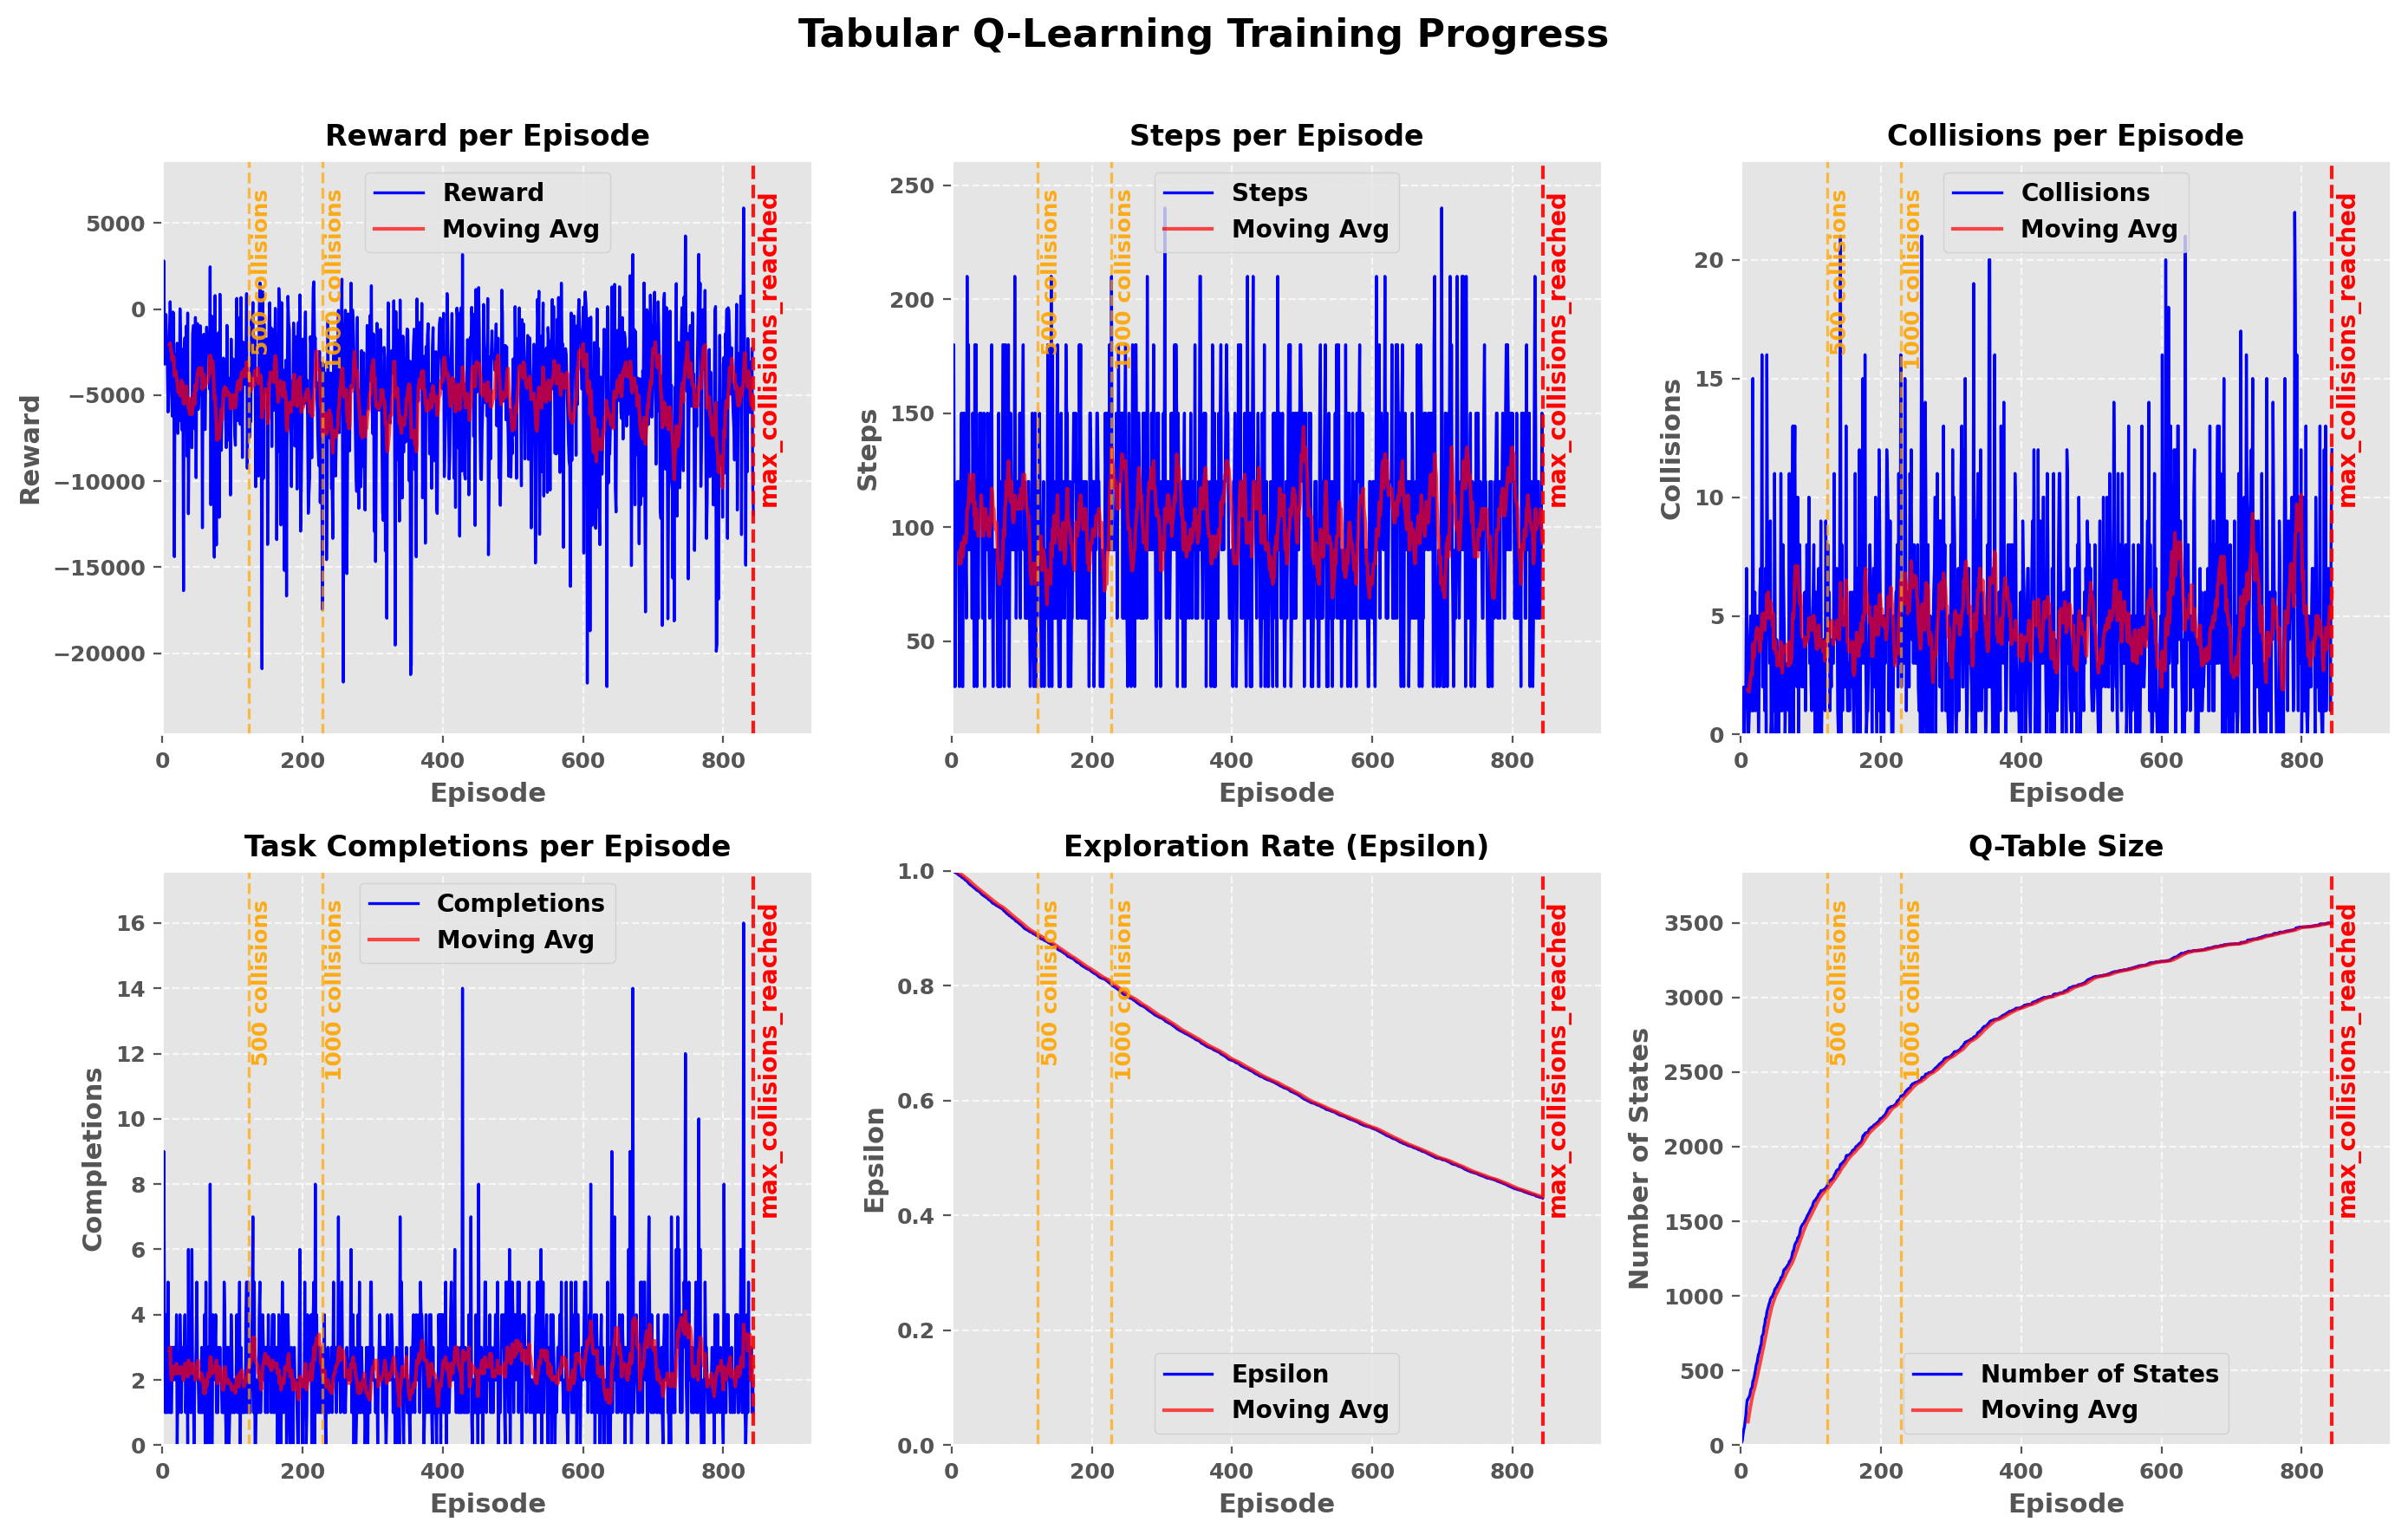

In [73]:
import numpy as np
import time
import random
import pickle
import os
from collections import defaultdict
from scipy.spatial import distance


class TabularQAgent:
    """
    Tabular Q-Learning agent for the transportation task.
    """

    def __init__(
        self,
        alpha=0.1,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=100000,
    ):
        """
        Initialize the Tabular Q-Learning agent.

        Args:
            alpha: Learning rate (default: 0.1)
            gamma: Discount factor (default: 0.99)
            epsilon_start: Initial exploration rate (default: 1.0)
            epsilon_end: Final exploration rate (default: 0.01)
            epsilon_decay: Number of steps for epsilon decay (default: 100000)
        """
        self.q_table = defaultdict(lambda: np.zeros(4))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

    def observation_to_statekey(self, observation):
        """
        Convert an observation dictionary into a state representation suitable for Q-learning.
        """
        position = observation["position"]
        position_A = observation["position_A"]
        position_B = observation["position_B"]
        is_carrying = observation["is_carrying"]
        destination = position_B if is_carrying else position_A
        occupancies = observation["adjacent_occupancies"]

        return (
            position[0],
            position[1],
            destination[0],
            destination[1],
            occupancies[0],
            occupancies[1],
            occupancies[2],
            occupancies[3],
        )

    def select_action(self, observation, action_mask, evaluate=False):
        """
        Select an action using epsilon-greedy policy.
        """
        state = self.observation_to_statekey(observation)
        valid_actions = np.where(action_mask == 1)[0]

        if evaluate or random.random() > self.epsilon:
            q_values = self.q_table[state].copy()

            # Set invalid actions to negative infinity
            q_values[action_mask == 0] = float("-inf")

            # Get actions with maximum value (handles ties)
            max_value = np.max(q_values)
            max_actions = np.where(q_values == max_value)[0]

            return random.choice(max_actions)
        else:
            return random.choice(valid_actions)

    def update_epsilon(self, steps=0):
        """
        Update the exploration rate (epsilon) using exponential decay.
        """
        self.epsilon = self.epsilon_end + (
            self.epsilon_start - self.epsilon_end
        ) * np.exp(-steps / self.epsilon_decay)
        return self.epsilon

    def update_q_value(
        self, state, action, reward, next_state, done=False, action_mask=None
    ):
        """
        Update Q-value using the Q-learning update rule.
        """
        current_q = self.q_table[state][action]

        if done:
            max_next_q = 0
        else:
            next_q_values = self.q_table[next_state].copy()

            # Apply action mask if provided
            if action_mask is not None:
                next_q_values[action_mask == 0] = float("-inf")

            max_next_q = np.max(next_q_values)
            if max_next_q == float("-inf"):
                max_next_q = 0

        # Q-learning update rule
        target = reward + self.gamma * max_next_q
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

        return self.q_table[state][action]

    def save(self, filepath):
        """
        Save the Q-table and agent parameters to a file.
        """
        # Ensure directory exists
        os.makedirs(os.path.dirname(filepath), exist_ok=True)

        # Convert defaultdict to regular dict for saving
        data = {
            "q_table": dict(self.q_table),
            "alpha": self.alpha,
            "gamma": self.gamma,
            "epsilon": self.epsilon,
            "epsilon_start": self.epsilon_start,
            "epsilon_end": self.epsilon_end,
            "epsilon_decay": self.epsilon_decay,
        }

        with open(filepath, "wb") as f:
            pickle.dump(data, f)

        print(f"Agent saved to {filepath}")

    @classmethod
    def load(cls, filepath):
        """
        Load a Q-table and agent parameters from a file.
        """
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        agent = cls(
            alpha=data["alpha"],
            gamma=data["gamma"],
            epsilon_start=data["epsilon_start"],
            epsilon_end=data["epsilon_end"],
            epsilon_decay=data["epsilon_decay"],
        )

        # Restore the Q-table
        agent.q_table = defaultdict(lambda: np.zeros(4))
        for state, values in data["q_table"].items():
            agent.q_table[state] = values

        agent.epsilon = data["epsilon"]

        print(
            f"Agent loaded from {filepath} with {len(agent.q_table)} state-action pairs"
        )

        return agent


def train_tabular_q(
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=10000,
    max_steps=1_500_000,
    max_episodes=200000,
    max_collisions=4000,
    max_time=600,  # 10 minutes
    collision_checkpoints=[500, 1000],
    use_plotter=True,
):
    """
    Train a Tabular Q-learning agent on the transportation task.
    """
    # Create directories
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)

    # Initialize environment and agent
    environment = env()  # MODE_TRAINING=1
    agent = TabularQAgent(
        alpha=alpha,
        gamma=gamma,
        epsilon_start=epsilon_start,
        epsilon_end=epsilon_end,
        epsilon_decay=epsilon_decay,
    )

    # Initialize plotter if requested
    plotter = None
    if use_plotter:
        try:
            plotter = TrainingPlotter(agent_type="tabular")
            print("Training visualization enabled")
        except ImportError:
            print("Warning: Could not import TrainingPlotter. Visualization disabled.")

    # Training metrics
    total_steps = 0
    total_collisions = 0
    current_episode = 0
    training_start_time = time.time()

    # Sort collision checkpoints for consistent tracking
    collision_checkpoints = sorted(collision_checkpoints)
    next_checkpoint_idx = 0

    print("Starting Tabular Q-Learning training...")
    print(f"Alpha: {alpha}, Gamma: {gamma}, Epsilon: {epsilon_start} → {epsilon_end}")

    # Training status tracking
    status = "completed"

    try:
        # Main training loop
        for _ in range(max_episodes):
            if total_steps >= max_steps:
                status = "max_steps_reached"
                break

            # Reset environment in training mode
            environment.reset()

            # Calculate dynamic episode length based on A-B distance
            position_A = environment.position_A
            position_B = environment.position_B
            max_episode_steps = 30 * distance.cityblock(position_A, position_B)

            # Episode metrics
            episode_steps = 0
            episode_reward = 0

            # Episode loop
            while environment.agents and environment.steps < max_episode_steps:
                if environment.agent_selection not in environment.agents:
                    environment.agent_selection = environment.agents[0]

                # Get observation
                observation, _, termination, _, info = environment.last()

                # Skip if agent is terminated
                if termination:
                    environment.step(None)
                    continue

                # Select and execute action
                action = agent.select_action(observation, info["action_mask"])
                current_state = agent.observation_to_statekey(observation)

                environment.step(action)

                # Get updated state
                new_observation, new_reward, new_termination, _, new_info = (
                    environment.last()
                )
                episode_reward += new_reward

                # Update Q-value
                next_state = agent.observation_to_statekey(new_observation)
                agent.update_q_value(
                    current_state,
                    action,
                    new_reward,
                    next_state,
                    new_termination,
                    new_info["action_mask"],
                )

                # Update epsilon
                agent.update_epsilon(total_steps)

            # Update metrics
            episode_collisions = environment.collisions
            episode_steps = environment.steps
            episode_completions = environment.completions

            total_collisions += episode_collisions
            total_steps += episode_steps
            current_episode += 1

            # Update plotter
            if use_plotter and plotter is not None:
                plotter.update(
                    episode=current_episode,
                    reward=episode_reward,
                    steps=episode_steps,
                    collisions=episode_collisions,
                    completions=episode_completions,
                    q_table_size=len(agent.q_table),
                    epsilon=agent.epsilon,
                )

            # Progress output (every 10 episodes)
            if current_episode % 10 == 0:
                elapsed_time = time.time() - training_start_time
                print(
                    f"Ep: {current_episode}/{max_episodes} | "
                    f"Steps: {total_steps}/{max_steps} | "
                    f"Time: {elapsed_time:.1f}s | "
                    f"ε: {agent.epsilon:.3f} | "
                    f"Q-size: {len(agent.q_table)} | "
                    f"Ep Coll: {episode_collisions} | "
                    f"Total Coll: {total_collisions} | "
                    f"Comp: {episode_completions} | "
                    f"Reward: {episode_reward:.1f}"
                )

            # Check collision checkpoints
            if (
                next_checkpoint_idx < len(collision_checkpoints)
                and total_collisions >= collision_checkpoints[next_checkpoint_idx]
            ):
                checkpoint = collision_checkpoints[next_checkpoint_idx]
                checkpoint_path = f"models/tabular_q_agent_coll{checkpoint}.pkl"
                agent.save(checkpoint_path)

                if use_plotter and plotter is not None:
                    plotter.add_stopping_point(
                        current_episode, f"{checkpoint} collisions"
                    )

                next_checkpoint_idx += 1

            # Check stopping conditions
            if total_collisions >= max_collisions:
                status = "max_collisions_reached"
                break

            if time.time() - training_start_time >= max_time:
                status = "max_time_reached"
                break

    except KeyboardInterrupt:
        status = "user_interrupted"
        print("Training interrupted by user")

    # Record final stopping point for plotter
    if use_plotter and plotter is not None:
        plotter.add_stopping_point(current_episode, status)

    # Save final model
    final_save_path = f"models/tabular_q_agent_final_{status}.pkl"
    agent.save(final_save_path)

    # Display and save plot
    if use_plotter and plotter is not None:
        plot_path = "plots/tabular_q_agent_training_plot.png"
        plotter.show()
        plotter.save(plot_path)
        print(f"Training plot saved to {plot_path}")

    # Print summary
    training_time = time.time() - training_start_time
    print("\nTraining complete!")
    print(f"Total episodes: {current_episode}")
    print(f"Total steps: {total_steps}")
    print(f"Total collisions: {total_collisions}")
    print(f"Training time: {training_time:.2f}s")
    print(f"Q-table size: {len(agent.q_table)}")
    print(f"Final model saved to {final_save_path}")
    print(f"Status: {status}")

    return agent


print("Starting training mode...")

# Training configuration
config = {
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 100000,
    "max_episodes": 200000,
    "max_collisions": 4000,
    "max_steps": 1500000,
    "max_time": 600,  # 10 minutes
    "collision_checkpoints": [500, 1000],
    "use_plotter": True,  # Set to False to disable plotting
}

TQ_agent = train_tabular_q(**config)

### **DQN**

Starting training mode...
Training visualization enabled
Starting DQN Training...
Device: cuda
Batch Size: 64, Learning Rate: 0.0001
Epsilon: 1.0 → 0.01, Decay: 4000
Ep: 10/20000 | Steps: 717/1500000 | Time: 1.9s | ε: 0.838 | Ep Coll: 0 | Total Coll: 21 | Comp: 2 | Reward: 155.0 | Loss: 19.9021
Target network updated at step 1000
Ep: 20/20000 | Steps: 1121/1500000 | Time: 3.0s | ε: 0.758 | Ep Coll: 0 | Total Coll: 28 | Comp: 2 | Reward: 200.0 | Loss: 22.2297
Ep: 30/20000 | Steps: 1624/1500000 | Time: 4.6s | ε: 0.670 | Ep Coll: 3 | Total Coll: 40 | Comp: 2 | Reward: -1366.0 | Loss: 16.8699
Ep: 40/20000 | Steps: 1988/1500000 | Time: 5.6s | ε: 0.612 | Ep Coll: 0 | Total Coll: 47 | Comp: 2 | Reward: 198.0 | Loss: 18.6025
Target network updated at step 2000
Ep: 50/20000 | Steps: 2344/1500000 | Time: 6.8s | ε: 0.561 | Ep Coll: 1 | Total Coll: 59 | Comp: 2 | Reward: -463.0 | Loss: 18.5790
Ep: 60/20000 | Steps: 2694/1500000 | Time: 7.9s | ε: 0.515 | Ep Coll: 0 | Total Coll: 67 | Comp: 2 | Rewa

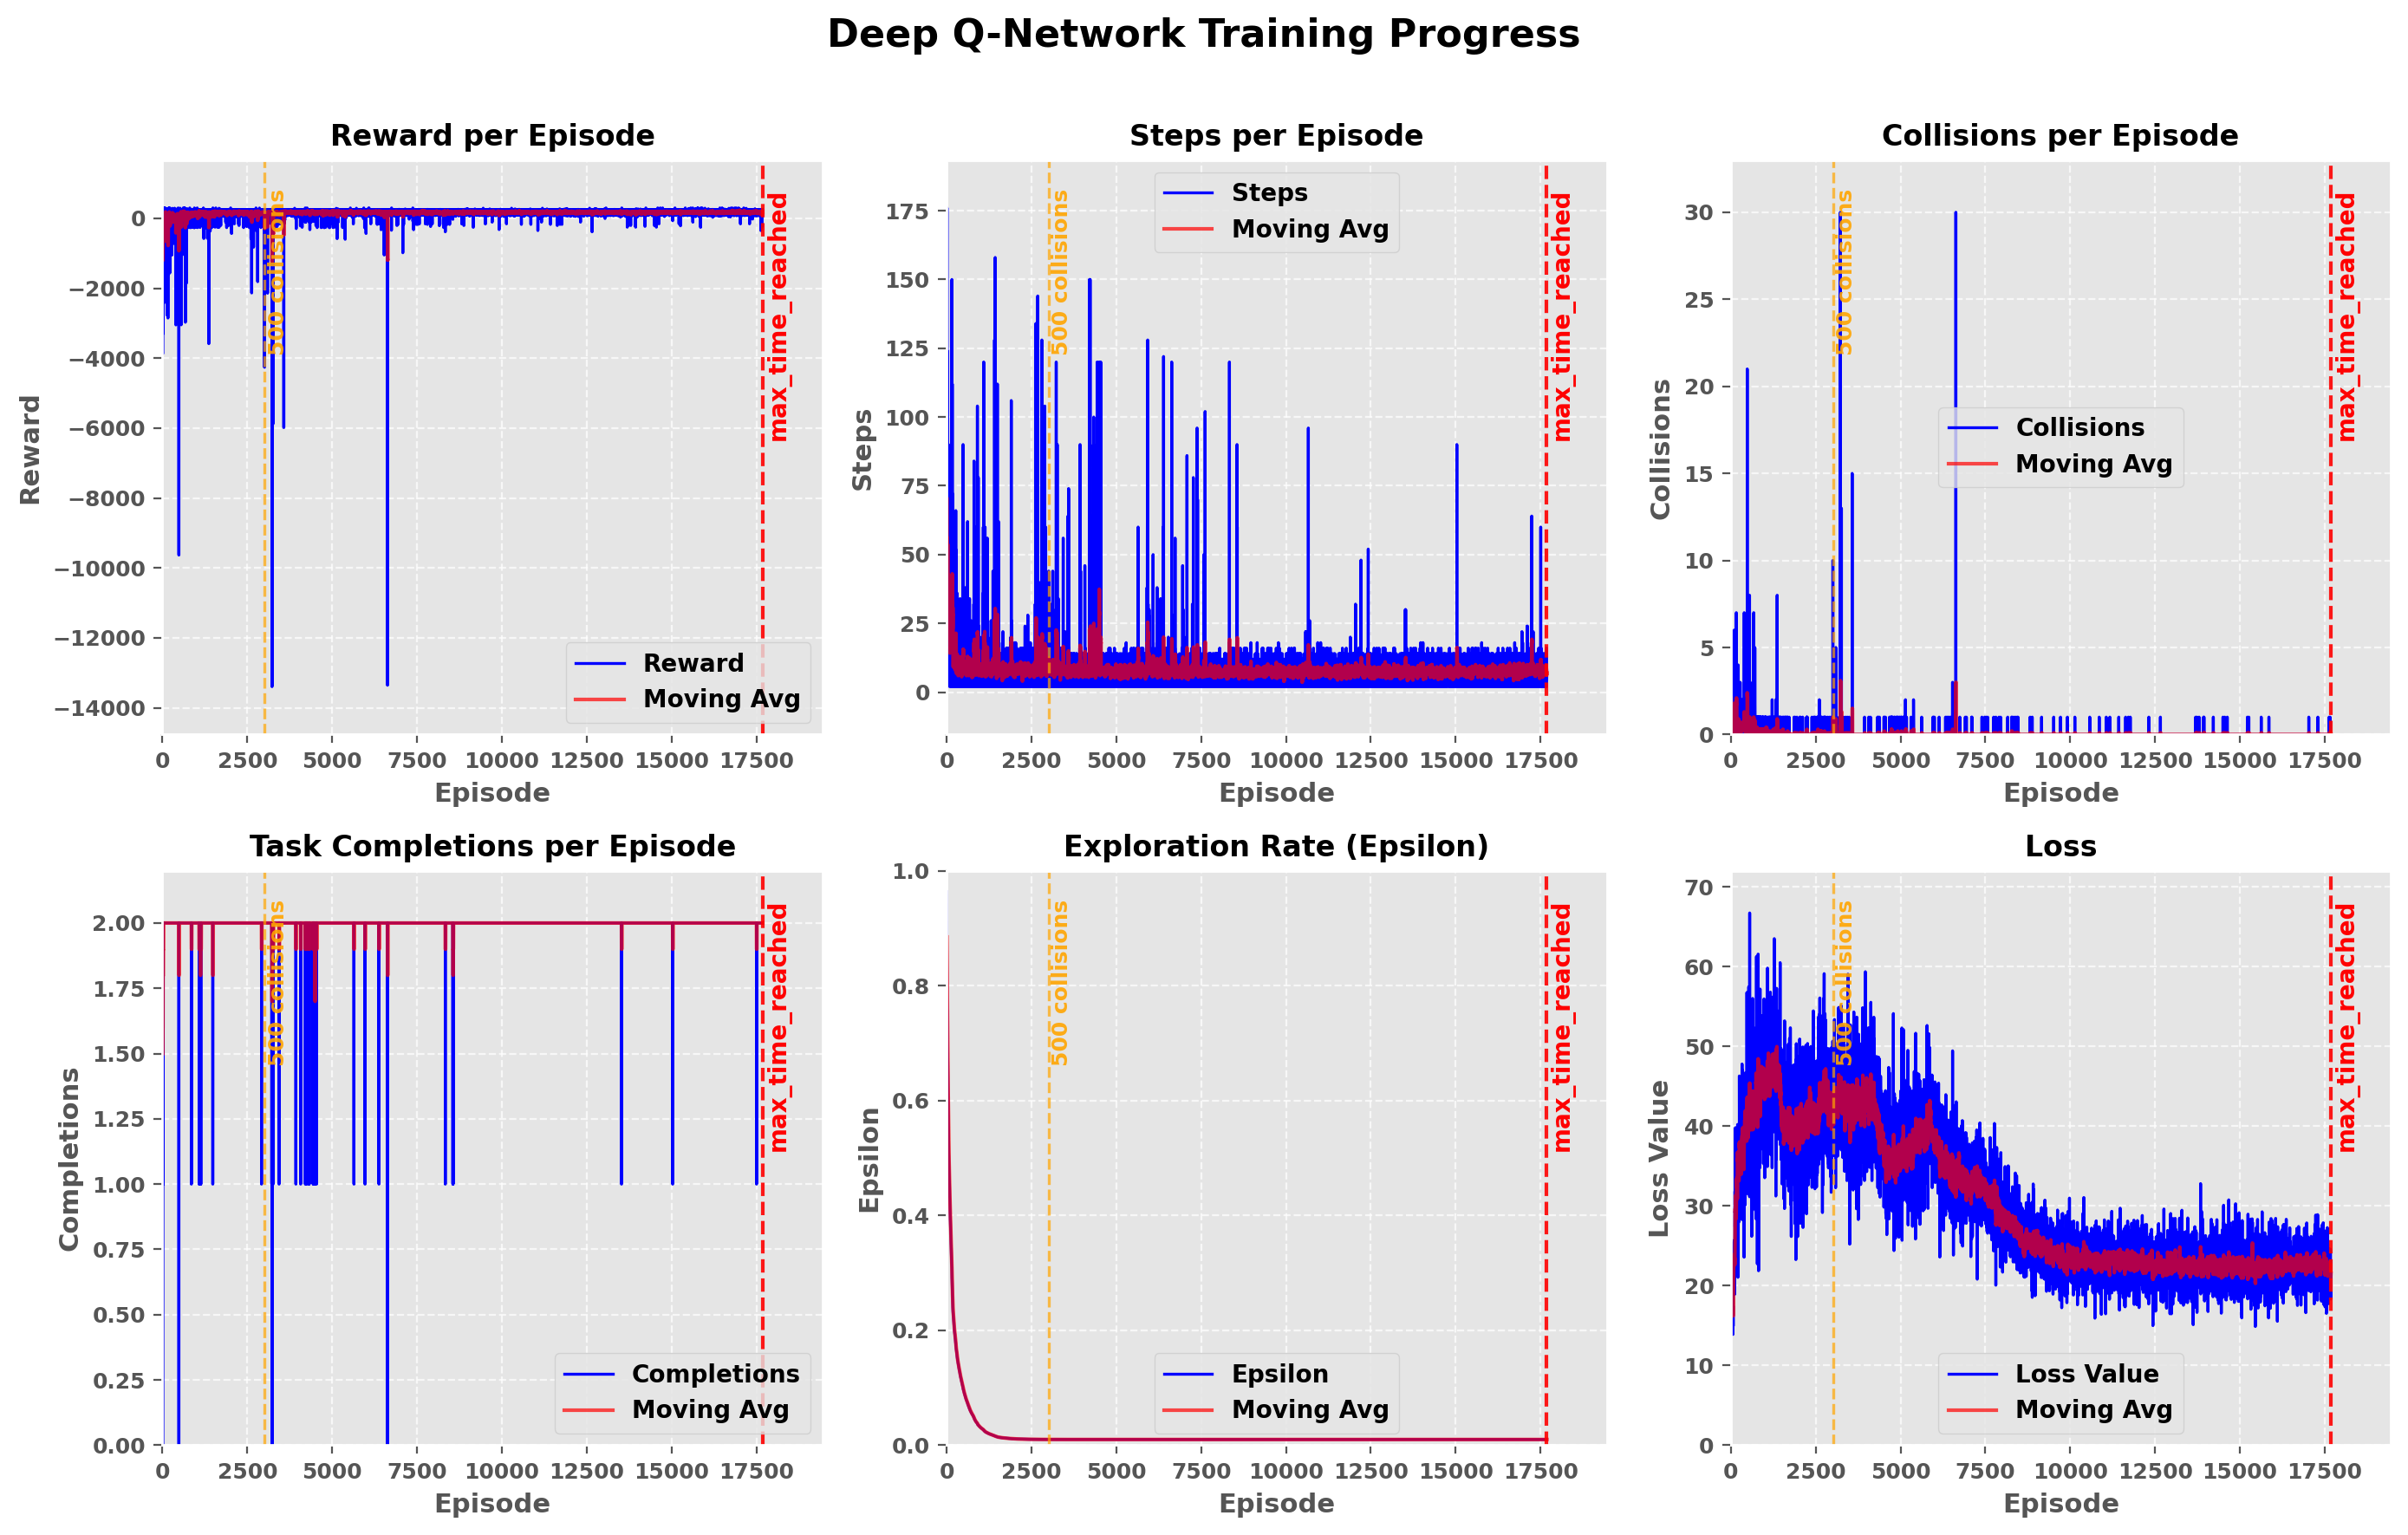

In [74]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import time
import math
from collections import deque, namedtuple
from scipy.spatial import distance
import os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Experience replay components
Experience = namedtuple(
    "Experience", ("state", "action", "next_state", "reward", "done")
)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(Experience(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


class DQN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.network(x)


class DQNAgent:
    """
    Deep Q-Learning agent for the transportation task.
    """

    def __init__(
        self,
        batch_size=64,
        gamma=0.99,
        learning_rate=0.0001,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=4000,
        target_update=1000,
        memory_size=10000,
    ):
        """Initialize the Deep Q-Learning agent."""
        # Network dimensions
        self.state_dim = 8  # position(2) + destination(2) + adjacent_occupancies(4)
        self.action_dim = 4  # North, South, East, West

        # Initialize networks
        self.policy_net = DQN(self.state_dim, self.action_dim).to(device)
        self.target_net = DQN(self.state_dim, self.action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Initialize optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)

        # Initialize replay memory
        self.memory = ReplayMemory(memory_size)

        # Training parameters
        self.batch_size = batch_size
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.epsilon_start = epsilon_start
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.target_update = target_update

    def observation_to_statetensor(self, observation):
        """Convert observation dict to tensor for network input."""
        # Extract components
        position = observation["position"]
        is_carrying = observation["is_carrying"]
        destination = (
            observation["position_B"] if is_carrying else observation["position_A"]
        )
        adjacent_occupancies = observation["adjacent_occupancies"]

        # Create state tensor
        state = np.concatenate([position, destination, adjacent_occupancies])
        return torch.FloatTensor(state).to(device)

    def select_action(self, observation, action_mask, evaluate=False):
        """Select action using epsilon-greedy policy with action masking."""
        state = self.observation_to_statetensor(observation)
        valid_actions = np.where(action_mask == 1)[0]

        # Use greedy policy when evaluating or based on epsilon
        if evaluate or random.random() > self.epsilon:
            with torch.no_grad():
                q_values = self.policy_net(state)

                # Apply action mask by setting invalid actions to negative infinity
                masked_q_values = q_values.clone()
                for i in range(self.action_dim):
                    if i not in valid_actions:
                        masked_q_values[i] = -float("inf")

                return masked_q_values.argmax().item()
        else:
            # Random action from valid actions during exploration
            return random.choice(valid_actions)

    def update_epsilon(self, steps=0):
        """Update the exploration rate (epsilon) using exponential decay."""
        self.epsilon = self.epsilon_end + (
            self.epsilon_start - self.epsilon_end
        ) * math.exp(-steps / self.epsilon_decay)
        return self.epsilon

    def optimize_model(self):
        """Perform one optimization step using a batch of experiences."""
        if len(self.memory) < self.batch_size:
            return None

        # Sample batch of experiences
        experiences = self.memory.sample(self.batch_size)
        batch = Experience(*zip(*experiences))

        # Prepare tensors
        state_batch = torch.cat(batch.state)
        action_batch = torch.tensor(
            batch.action, dtype=torch.int64, device=device
        ).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=device)
        next_state_batch = torch.cat([s for s in batch.next_state if s is not None])
        done_batch = torch.tensor(batch.done, dtype=torch.bool, device=device)

        # Compute Q(s_t, a) - the model computes Q(s_t), then we select the actions taken
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Compute target values (all at once, with proper gradient handling)
        with torch.no_grad():
            # Get next state values from target network
            next_q_values = self.target_net(next_state_batch)
            # Get max value for each next state
            max_next_q_values = next_q_values.max(1)[0]
            # For terminal states, future value is zero
            max_next_q_values[done_batch] = 0.0
            # Compute expected values
            expected_state_action_values = reward_batch + (
                self.gamma * max_next_q_values
            )

        # Compute loss using Huber loss (smooth L1)
        loss = F.smooth_l1_loss(
            state_action_values, expected_state_action_values.unsqueeze(1)
        )

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for stability
        for param in self.policy_net.parameters():
            param.grad.data.clamp_(-1, 1)

        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Update target network by copying parameters from policy network"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def save(self, path="models/dqn_model.pth"):
        """Save the trained DQN model."""
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(path), exist_ok=True)

        torch.save(
            {
                "policy_net_state_dict": self.policy_net.state_dict(),
                "target_net_state_dict": self.target_net.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "epsilon": self.epsilon,
                "gamma": self.gamma,
                "learning_rate": self.learning_rate,
                "epsilon_start": self.epsilon_start,
                "epsilon_end": self.epsilon_end,
                "epsilon_decay": self.epsilon_decay,
                "target_update": self.target_update,
                "batch_size": self.batch_size,
            },
            path,
        )
        print(f"Model saved to {path}")
        return path

    @classmethod
    def load(cls, path="models/dqn_model.pth"):
        """Load a trained DQN model."""
        # Load checkpoint
        checkpoint = torch.load(path, map_location=device)

        # Create agent with saved parameters
        agent = cls(
            batch_size=checkpoint.get("batch_size", 64),
            gamma=checkpoint.get("gamma", 0.99),
            learning_rate=checkpoint.get("learning_rate", 0.0001),
            epsilon_start=checkpoint.get("epsilon_start", 1.0),
            epsilon_end=checkpoint.get("epsilon_end", 0.01),
            epsilon_decay=checkpoint.get("epsilon_decay", 4000),
            target_update=checkpoint.get("target_update", 1000),
        )

        # Load state dictionaries
        agent.policy_net.load_state_dict(checkpoint["policy_net_state_dict"])
        agent.target_net.load_state_dict(checkpoint["target_net_state_dict"])
        agent.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        # Load exploration parameters
        agent.epsilon = checkpoint["epsilon"]

        print(f"Model loaded from {path}")
        print(f"Epsilon: {agent.epsilon:.4f}")

        return agent


def train_dqn(
    batch_size=64,
    gamma=0.99,
    learning_rate=0.0001,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=4000,
    target_update=1000,
    memory_size=10000,
    max_steps=1_000_000,
    max_episodes=20000,
    max_collisions=4000,
    max_time=600,  # 10 minutes
    collision_checkpoints=[500, 1000, 2000],
    use_plotter=False,
):
    """Train a Deep Q-learning agent on the transportation task."""
    # Create directories
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)
    torch.set_grad_enabled(True)
    # Initialize environment and agent
    environment = env()
    agent = DQNAgent(
        batch_size=batch_size,
        gamma=gamma,
        learning_rate=learning_rate,
        epsilon_start=epsilon_start,
        epsilon_end=epsilon_end,
        epsilon_decay=epsilon_decay,
        target_update=target_update,
        memory_size=memory_size,
    )

    # Initialize plotter if requested
    plotter = None
    if use_plotter:
        try:
            plotter = TrainingPlotter(agent_type="dqn")
            print("Training visualization enabled")
        except ImportError:
            print("Warning: Could not import TrainingPlotter. Visualization disabled.")

    # Training metrics
    total_steps = 0
    total_collisions = 0
    current_episode = 0
    training_start_time = time.time()
    latest_loss = None

    # Sort collision checkpoints for consistent tracking
    collision_checkpoints = sorted(collision_checkpoints)
    next_checkpoint_idx = 0

    print("Starting DQN Training...")
    print(f"Device: {device}")
    print(f"Batch Size: {batch_size}, Learning Rate: {learning_rate}")
    print(f"Epsilon: {epsilon_start} → {epsilon_end}, Decay: {epsilon_decay}")

    # Training status tracking
    status = "completed"

    try:
        # Main training loop
        for _ in range(max_episodes):
            if total_steps >= max_steps:
                status = "max_steps_reached"
                break

            # Reset environment in training mode
            environment.reset(options={"mode": 1})  # MODE_TRAINING=1

            # Calculate dynamic episode length based on A-B distance
            position_A = environment.position_A
            position_B = environment.position_B
            max_episode_steps = 30 * distance.cityblock(position_A, position_B)

            # Episode metrics
            episode_steps = 0
            episode_reward = 0
            episode_losses = []

            # Episode loop
            while environment.agents and environment.steps < max_episode_steps:
                if environment.agent_selection not in environment.agents:
                    environment.agent_selection = environment.agents[0]

                # Get current state
                observation, _, termination, _, info = environment.last()

                if termination:
                    # Agent is done - step without action to advance environment
                    environment.step(None)
                else:
                    # Select and execute action
                    action_mask = info["action_mask"]
                    action = agent.select_action(observation, action_mask)

                    # Store current state
                    state_tensor = agent.observation_to_statetensor(observation)

                    # Execute action
                    environment.step(action)

                    # Get updated state
                    (
                        new_observation,
                        new_reward,
                        new_termination,
                        _,
                        _,
                    ) = environment.last()
                    episode_reward += new_reward
                    next_state_tensor = agent.observation_to_statetensor(
                        new_observation
                    )

                    # Store transition in replay memory
                    agent.memory.push(
                        state_tensor.unsqueeze(0),
                        action,
                        next_state_tensor.unsqueeze(0),
                        new_reward,
                        new_termination,
                    )

                    # Optimize model if enough samples
                    if len(agent.memory) >= batch_size:
                        loss = agent.optimize_model()
                        if loss is not None:
                            latest_loss = loss
                            episode_losses.append(loss)

                # Update epsilon
                agent.update_epsilon(total_steps)

                # Update target network periodically
                if total_steps % target_update == 0 and total_steps > 0:
                    agent.update_target_network()
                    print(f"Target network updated at step {total_steps}")

                # Increment step counter
                total_steps += 1

            # Update metrics
            episode_collisions = environment.collisions
            episode_steps = environment.steps
            episode_completions = environment.completions

            total_collisions += episode_collisions
            current_episode += 1

            # Calculate average loss
            avg_loss = np.mean(episode_losses) if episode_losses else float("nan")

            # Update plotter
            if use_plotter and plotter is not None:
                plotter.update(
                    episode=current_episode,
                    reward=episode_reward,
                    steps=episode_steps,
                    collisions=episode_collisions,
                    completions=episode_completions,
                    loss=avg_loss,
                    epsilon=agent.epsilon,
                )

            # Progress output (every 10 episodes)
            if current_episode % 10 == 0:
                elapsed_time = time.time() - training_start_time
                print(
                    f"Ep: {current_episode}/{max_episodes} | "
                    f"Steps: {total_steps}/{max_steps} | "
                    f"Time: {elapsed_time:.1f}s | "
                    f"ε: {agent.epsilon:.3f} | "
                    f"Ep Coll: {episode_collisions} | "
                    f"Total Coll: {total_collisions} | "
                    f"Comp: {episode_completions} | "
                    f"Reward: {episode_reward:.1f}"
                    + (f" | Loss: {avg_loss:.4f}" if not math.isnan(avg_loss) else "")
                )

            # Check collision checkpoints
            if (
                next_checkpoint_idx < len(collision_checkpoints)
                and total_collisions >= collision_checkpoints[next_checkpoint_idx]
            ):
                checkpoint = collision_checkpoints[next_checkpoint_idx]
                checkpoint_path = f"models/dqn_model_coll{checkpoint}.pth"
                agent.save(checkpoint_path)

                if use_plotter and plotter is not None:
                    plotter.add_stopping_point(
                        current_episode, f"{checkpoint} collisions"
                    )

                next_checkpoint_idx += 1

            # Check stopping conditions
            if total_collisions >= max_collisions:
                status = "max_collisions_reached"
                break

            if time.time() - training_start_time >= max_time:
                status = "max_time_reached"
                break

    except KeyboardInterrupt:
        status = "user_interrupted"
        print("Training interrupted by user")

    # Record final stopping point for plotter
    if use_plotter and plotter is not None:
        plotter.add_stopping_point(current_episode, status)

    # Save final model
    final_save_path = f"models/dqn_model_final_{status}.pth"
    agent.save(final_save_path)

    # Display and save plot
    if use_plotter and plotter is not None:
        plot_path = "plots/dqn_training_plot.png"
        plotter.show()
        plotter.save(plot_path)
        print(f"Training plot saved to {plot_path}")

    # Print summary
    training_time = time.time() - training_start_time
    print("\nTraining complete!")
    print(f"Total episodes: {current_episode}")
    print(f"Total steps: {total_steps}")
    print(f"Total collisions: {total_collisions}")
    print(f"Training time: {training_time:.2f}s")
    if not math.isnan(latest_loss or float("nan")):
        print(f"Final loss: {latest_loss:.4f}")
    print(f"Final model saved to {final_save_path}")
    print(f"Status: {status}")

    return agent


print("Starting training mode...")

# Training configuration
config = {
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 0.0001,
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 4000,
    "target_update": 1000,
    "memory_size": 10000,
    "max_episodes": 20000,
    "max_collisions": 4000,
    "max_steps": 1500000,
    "max_time": 600,  # 10 minutes
    "collision_checkpoints": [500, 1000],
    "use_plotter": True,  # Set to False to disable plotting
}

DQN_agent = train_dqn(**config)


## Test Case Generation (3,000 Configurations)

Our evaluation tested each algorithm across 3,000 distinct scenarios derived from:
- All possible combinations of locations A and B in the 5×5 grid (25×24 = 600 position pairs)
- 5 different agent distributions (varying the number of agents starting at position B from 0 to 4)
- Total test cases: 600 position pairs × 5 distributions = 3,000 configurations

## Evaluation Method

We evaluated both algorithms based on:
1. **Success Rate**: Percentage of scenarios completed without collisions
2. **Path Efficiency**: Average steps needed for task completion 
3. **Learning Speed**: Performance at checkpoints (500 and 1,000 collisions)
4. **Performance Levels**: Categorized as Level 1 (≥75%), Level 2 (≥85%), or Level 3 (≥95%)

This comprehensive testing approach ensures the algorithms' performance is evaluated across the full range of possible task configurations, providing reliable metrics for comparison.


In [75]:
from tqdm import tqdm

# Success rate thresholds for performance levels
SUCCESS_THRESHOLDS = {
    1: 0.75,  # Level 1: 75%
    2: 0.85,  # Level 2: 85%
    3: 0.95,  # Level 3: 95%
}


def test_agent(agent, agent_type, max_steps=25, verbose=True):
    """
    Test an agent on all configurations of A and B positions and agent distributions.

    Args:
        agent: The trained agent (DQNAgent or TabularQAgent)
        max_steps: Maximum steps per scenario
        verbose: Whether to print detailed results
    """
    environment = env()

    # Get all grid positions
    all_positions = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]

    # Tracking metrics
    total_scenarios = 0
    successful_scenarios = 0
    total_steps_taken = 0
    collision_count = 0
    timeout_count = 0

    # Calculate total number of scenarios
    num_position_pairs = GRID_SIZE * GRID_SIZE * (GRID_SIZE * GRID_SIZE - 1)
    num_agent_distributions = NUM_AGENTS + 1  # 0 to NUM_AGENTS agents at B
    total_test_cases = num_position_pairs * num_agent_distributions

    # Set up progress tracking
    if verbose:
        print(
            f"Testing {agent_type.upper()} agent across {total_test_cases} configurations"
        )
        print(
            f"Grid: {GRID_SIZE}x{GRID_SIZE}, Agents: {NUM_AGENTS}, Max steps: {max_steps}"
        )
        iterator = tqdm(total=total_test_cases)
    else:
        iterator = range(total_test_cases)

    # Test all configurations
    for num_B_agents in range(NUM_AGENTS + 1):
        for pos_A in all_positions:
            for pos_B in all_positions:
                # Skip if A and B are the same position
                if pos_A == pos_B:
                    continue

                total_scenarios += 1

                # Reset environment with specific configuration
                environment.reset(
                    options={
                        "A_position": pos_A,
                        "B_position": pos_B,
                        "mode": 2,  # MODE_TESTING
                        "num_B_agents": num_B_agents,
                    }
                )

                # Run scenario
                steps = {agent: 0 for agent in environment.agents}
                success = False

                # Scenario loop
                while (
                    environment.agents
                    and steps[environment.agent_selection] < max_steps
                ):
                    if environment.agent_selection not in environment.agents:
                        environment.agent_selection = environment.agents[0]

                    # Get observation and select action
                    observation, _, _, _, info = environment.last()
                    action = agent.select_action(
                        observation, info["action_mask"], evaluate=True
                    )

                    # Execute action
                    environment.step(action)
                    steps[environment.agent_selection] += 1

                    # Check for collision
                    if environment.collisions > 0:
                        collision_count += 1
                        break

                    # Success condition: enough completions for at least one full cycle
                    if environment.completions >= NUM_AGENTS:
                        success = True
                        successful_scenarios += 1
                        total_steps_taken += steps[environment.agent_selection]
                        break

                # Count timeout
                if not success and environment.collisions == 0:
                    timeout_count += 1

                # Update progress bar
                if verbose and hasattr(iterator, "update"):
                    iterator.update(1)

    # Close progress bar
    if verbose and hasattr(iterator, "close"):
        iterator.close()

    # Calculate metrics
    success_rate = successful_scenarios / total_scenarios if total_scenarios > 0 else 0
    avg_steps = (
        total_steps_taken / successful_scenarios if successful_scenarios > 0 else 0
    )

    # Determine performance level
    performance_level = 0
    for level in [3, 2, 1]:
        if success_rate >= SUCCESS_THRESHOLDS[level]:
            performance_level = level
            break

    # Print results
    print(f"\n=== {agent_type.upper()} Test Results ===")
    print(
        f"Success Rate: {success_rate:.2%} ({successful_scenarios}/{total_scenarios})"
    )
    print(f"Average Steps: {avg_steps:.2f}")
    print(f"Collisions: {collision_count}")
    print(f"Timeouts: {timeout_count}")

    # Print performance level with stars
    level_stars = "★" * performance_level + "☆" * (3 - performance_level)
    print(f"Performance Level: {level_stars} (Level {performance_level})")
    if performance_level > 0:
        print(f"Achieved {SUCCESS_THRESHOLDS[performance_level]:.0%}+ success rate")

In [76]:
# Test the trained agent
test_agent(TQ_agent, agent_type="Tabular-Q", max_steps=25, verbose=True)

Testing TABULAR-Q agent across 3000 configurations
Grid: 5x5, Agents: 4, Max steps: 25


100%|██████████| 3000/3000 [00:07<00:00, 413.23it/s]


=== TABULAR-Q Test Results ===
Success Rate: 7.43% (223/3000)
Average Steps: 3.14
Collisions: 303
Timeouts: 2474
Performance Level: ☆☆☆ (Level 0)


In [77]:
test_agent(DQN_agent, agent_type="DQN", max_steps=25, verbose=True)

Testing DQN agent across 3000 configurations
Grid: 5x5, Agents: 4, Max steps: 25


100%|██████████| 3000/3000 [00:21<00:00, 137.09it/s]


=== DQN Test Results ===
Success Rate: 100.00% (3000/3000)
Average Steps: 3.68
Collisions: 0
Timeouts: 0
Performance Level: ★★★ (Level 3)
Achieved 95%+ success rate


# Comparative Analysis: DQN vs. Tabular Q-Learning

## Training Metrics

| Metric | Tabular-Q | DQN |
|--------|-----------|-----|
| Episodes | 810 (terminated early) | 15,930 (completed) |
| Training time | 3.2 seconds | 599.9 seconds |
| Total steps | 81,240 (5.4% of budget) | 166,093 (11% of budget) |
| Final epsilon | 0.450 (insufficient decay) | 0.010 (properly decayed) |
| Total collisions | 3,948 (reached limit) | 570 |
| Collisions/episode | 4.87 | 0.036 |
| State representation | 3,500 Q-table states | Neural network approximation |

## Test Performance

| Metric | Tabular-Q | DQN |
|--------|-----------|-----|
| **Success Rate** | **8.87%** (266/3000) | **100.00%** (3000/3000) |
| Average Steps | 3.14 | 4.14 |
| Collisions | 290 | 0 |
| Timeouts | 2444 | 0 |

## Training Progression

### Tabular Q-Learning
- **Rewards**: Highly volatile (-18,764 to +1,232)
- **Collisions**: No systematic improvement; high-collision episodes persisted throughout
- **Task Completion**: Inconsistent, with no clear upward trend
- **State Space**: Q-table growth plateaued around 3,500 states
- **Final Episode**: 6 collisions, -6,076 reward, 0 completions

### DQN
- **Rewards**: Clear progression from deeply negative to stable/positive
- **Collisions**: Dramatic reduction; later episodes often collision-free
- **Task Completion**: Consistent improvement with stable final performance
- **Loss**: Steadily decreased and stabilized around 18-20
- **Final Episode**: 0 collisions, +240 reward, 2 completions

## Algorithm Comparison

| Aspect | Tabular Q-Learning | Deep Q-Network |
|--------|-------------------|----------------|
| **Implementation** | Simple | More complex |
| **Training Speed** | Fast (3.2s) | Slower (600s) |
| **Generalization** | Poor (8.87% success) | Excellent (100% success) |
| **State Space Handling** | Limited by table size | Neural network approximation |
| **Coordination Learning** | Failed to learn | Mastered coordination |
| **Resource Usage** | Exhausted collision budget | Efficient collision avoidance |
| **Transparency** | Explicit Q-values | Black-box representation |

## Conclusion

**DQN clearly outperforms Tabular Q-Learning** for this multi-agent coordination task:

1. **State Space Handling**: DQN's function approximation successfully generalized across the state space, while Tabular-Q's explicit representation failed to capture sufficient states.

2. **Learning Efficiency**: DQN required 135× fewer collisions per episode (0.036 vs. 4.87).

3. **Task Performance**: DQN achieved perfect test results (100% success with zero collisions), transforming an essentially unsolved problem (8.87% success) into a completely solved one.

Despite higher implementation complexity, **DQN is the recommended approach** for multi-agent coordination problems with large state spaces.

## Grid World Visualization

The simulation provides a real-time visualization of the multi-agent transportation task, displaying the agents' learned behaviors in an interactive environment. The visualization represents:

- **Location A** (green square): The pickup point where agents collect items
- **Location B** (red square): The delivery point where agents deposit items
- **Agents**: Color-coded circles with the following properties:
  - Filled circles indicate agents carrying items (traveling A→B)
  - Hollow circles indicate agents without items (traveling B→A)
  - Individual agents maintain consistent coloring across their representations and trails
  - Each agent displays its ID number for tracking purposes

The visualization dynamically tracks and displays key performance metrics:
- Steps executed
- Successful task completions
- Collision incidents

Agent movement history is represented by colored trails, providing insight into the path planning strategies. When multiple agents occupy the same cell, they are automatically positioned in different quadrants for clear visibility. Collision situations, where agents with opposing directives occupy the same cell, are highlighted with a red overlay.

This visualization effectively demonstrates the emergence of coordination behaviors as agents learn to establish efficient pathways while avoiding conflicts with other agents.


In [78]:
def visualize_agent(agent, steps=30, delay=0.3, seed=None):
    """
    Visualize an agent in the grid environment with improved visuals.
    """
    import matplotlib.pyplot as plt
    from IPython.display import display, clear_output
    import time
    
    # Make sure we're using inline display
    %matplotlib inline
    
    # Create environment with optional seed (using the already imported env class)
    environment = env()
    options = {"mode": 0}  # MODE_NORMAL
    if seed is not None:
        environment.reset(seed=seed, options=options)
    else:
        environment.reset(options=options)
    
    # Initialize visualization figure
    plt.figure(figsize=(8, 8))
    agent_trails = {}
    max_trail_length = 10
    grid_size = 5  # From env.py GRID_SIZE
    
    # Define agent colors - each agent gets a distinct color
    agent_colors = {
        'agent_0': '#FF5733',  # Orange-red
        'agent_1': '#33A3FF',  # Bright blue
        'agent_2': '#9E33FF',  # Purple
        'agent_3': '#33FF57'   # Bright green
    }
    
    def render():
        """Render the current state of the environment."""
        plt.clf()  # Clear the figure
        
        # Create axis with proper limits to show all cells completely
        ax = plt.gca()
        ax.set_xlim(-0.5, grid_size-0.5)
        ax.set_ylim(-0.5, grid_size-0.5)
        
        # Set white background
        ax.set_facecolor('white')
        
        # Draw grid - much thicker lines
        for i in range(grid_size+1):
            plt.axhline(i-0.5, color='#333333', linestyle='-', linewidth=2.0, alpha=0.8)
            plt.axvline(i-0.5, color='#333333', linestyle='-', linewidth=2.0, alpha=0.8)
        
        # Add a thick outer border
        outer_border = plt.Rectangle(
            (-0.5, -0.5), grid_size, grid_size, 
            fill=False, 
            edgecolor='#000000', 
            linewidth=4.0
        )
        ax.add_patch(outer_border)
        
        # Draw location A - vibrant green
        row_a, col_a = environment.position_A
        rect_a = plt.Rectangle((col_a-0.5, row_a-0.5), 1, 1, fill=True, color='#00BB00', alpha=0.5)
        ax.add_patch(rect_a)
        plt.text(col_a, row_a, "A", ha='center', va='center', fontsize=20, fontweight='bold', color='black')
        
        # Draw location B - vibrant red
        row_b, col_b = environment.position_B
        rect_b = plt.Rectangle((col_b-0.5, row_b-0.5), 1, 1, fill=True, color='#DD0000', alpha=0.5)
        ax.add_patch(rect_b)
        plt.text(col_b, row_b, "B", ha='center', va='center', fontsize=20, fontweight='bold', color='black')
        
        # Draw trails - using agent-specific colors
        for agent_id, trail in agent_trails.items():
            if len(trail) > 1:
                trail_x = [col for row, col in trail]
                trail_y = [row for row, col in trail]
                plt.plot(trail_x, trail_y, color=agent_colors.get(agent_id, 'blue'), alpha=0.6, linewidth=2.0)
        
        # Find and highlight collision cells
        collision_cells = []
        cell_occupants = {}
        
        # Group agents by position
        for agent_id in environment.agents:
            pos = tuple(environment._agent_positions[agent_id])
            carrying = environment._agent_is_carrying[agent_id]
            
            # Skip agents at locations A or B for collision detection
            if pos == tuple(environment.position_A) or pos == tuple(environment.position_B):
                continue
                
            if pos not in cell_occupants:
                cell_occupants[pos] = []
            cell_occupants[pos].append((agent_id, carrying))
        
        # Check for collisions
        for pos, occupants in cell_occupants.items():
            if len(occupants) > 1:
                carrying_states = [carrying for _, carrying in occupants]
                if True in carrying_states and False in carrying_states:
                    collision_cells.append(pos)
        
        # Highlight collision cells
        for pos in collision_cells:
            row, col = pos
            collision_rect = plt.Rectangle((col-0.5, row-0.5), 1, 1, fill=True, color='#FF0000', alpha=0.3)
            ax.add_patch(collision_rect)
        
        # Count how many agents are in each cell for positioning
        position_counts = {}
        position_indices = {}
        
        for agent_id in environment.agents:
            pos = tuple(environment._agent_positions[agent_id])
            if pos not in position_counts:
                position_counts[pos] = 0
                position_indices[pos] = {}
            position_indices[pos][agent_id] = position_counts[pos]
            position_counts[pos] += 1
        
        # Draw agents - properly sized for 4 agents per cell
        for agent_id in environment.agents:
            row, col = environment._agent_positions[agent_id]
            is_carrying = environment._agent_is_carrying[agent_id]
            agent_color = agent_colors.get(agent_id, 'blue')
            
            # Get agent's position index in the cell (0-3)
            pos = (row, col)
            idx = position_indices[pos][agent_id]
            
            # Calculate quadrant offsets based on index
            # 0: top-left, 1: top-right, 2: bottom-left, 3: bottom-right
            offsets = [(-0.25, 0.25), (0.25, 0.25), (-0.25, -0.25), (0.25, -0.25)]
            if idx < len(offsets):
                dx, dy = offsets[idx]
            else:
                # If somehow more than 4 agents in a cell, just use the center
                dx, dy = 0, 0
            
            # Draw agent with proper size (small enough for 4 per cell)
            circle = plt.Circle((col + dx, row + dy), 0.15, 
                              fill=is_carrying, 
                              color=agent_color, 
                              ec=agent_color, 
                              linewidth=2)
            ax.add_patch(circle)
            
            # Add agent number
            agent_num = int(agent_id.split('_')[1])
            plt.text(col + dx, row + dy, str(agent_num), 
                    ha='center', va='center', 
                    color='white' if is_carrying else 'black',
                    fontweight='bold', fontsize=8)
            
            # Update trail - use cell center for trails regardless of quadrant position
            if agent_id not in agent_trails:
                agent_trails[agent_id] = []
                
            # Add current position if different from last (use cell center for trails)
            if not agent_trails[agent_id] or (row, col) != agent_trails[agent_id][-1]:
                agent_trails[agent_id].append((row, col))
                
            # Limit trail length
            if len(agent_trails[agent_id]) > max_trail_length:
                agent_trails[agent_id] = agent_trails[agent_id][-max_trail_length:]
        
        # Add metrics text
        plt.title(f"Steps: {environment.steps} | Completions: {environment.completions} | Collisions: {environment.collisions}",
                 fontsize=12, fontweight='bold')
        
        # Remove axis ticks for cleaner look
        plt.xticks([])
        plt.yticks([])
        
        # Fix layout to ensure all grid cells are fully visible
        plt.tight_layout()
    
    # Run simulation
    print(f"Starting simulation with {len(environment.agents)} agents")
    print(f"Location A: {environment.position_A}, Location B: {environment.position_B}")
    
    # Display initial state
    render()
    display(plt.gcf())
    
    # Run for specified steps
    for step in range(steps):
        # End if no agents remain
        if not environment.agents:
            print("All agents completed their tasks!")
            break
            
        # Ensure valid agent selection
        if environment.agent_selection not in environment.agents:
            environment.agent_selection = environment.agents[0]
        
        # Get observation and action mask
        observation, _, termination, _, info = environment.last()
        
        # Skip terminated agents
        if termination:
            environment.step(None)
            continue
        
        # Get action from agent
        action = agent.select_action(observation, info["action_mask"], evaluate=True)
        
        # Execute action
        environment.step(action)
        
        # Render updated state
        clear_output(wait=True)
        render()
        display(plt.gcf())
        
        # Add delay
        time.sleep(delay)
    
   # Print summary
    print(f"\nSimulation summary:")
    print(f"- Steps taken: {environment.steps}")
    print(f"- Tasks completed: {environment.completions}")
    print(f"- Collisions occurred: {environment.collisions}")
    
    # Store metrics to return
    results = (environment.completions, environment.collisions, environment.steps)
    
    # Close the figure to prevent duplicate display
    plt.close()
    
    return results

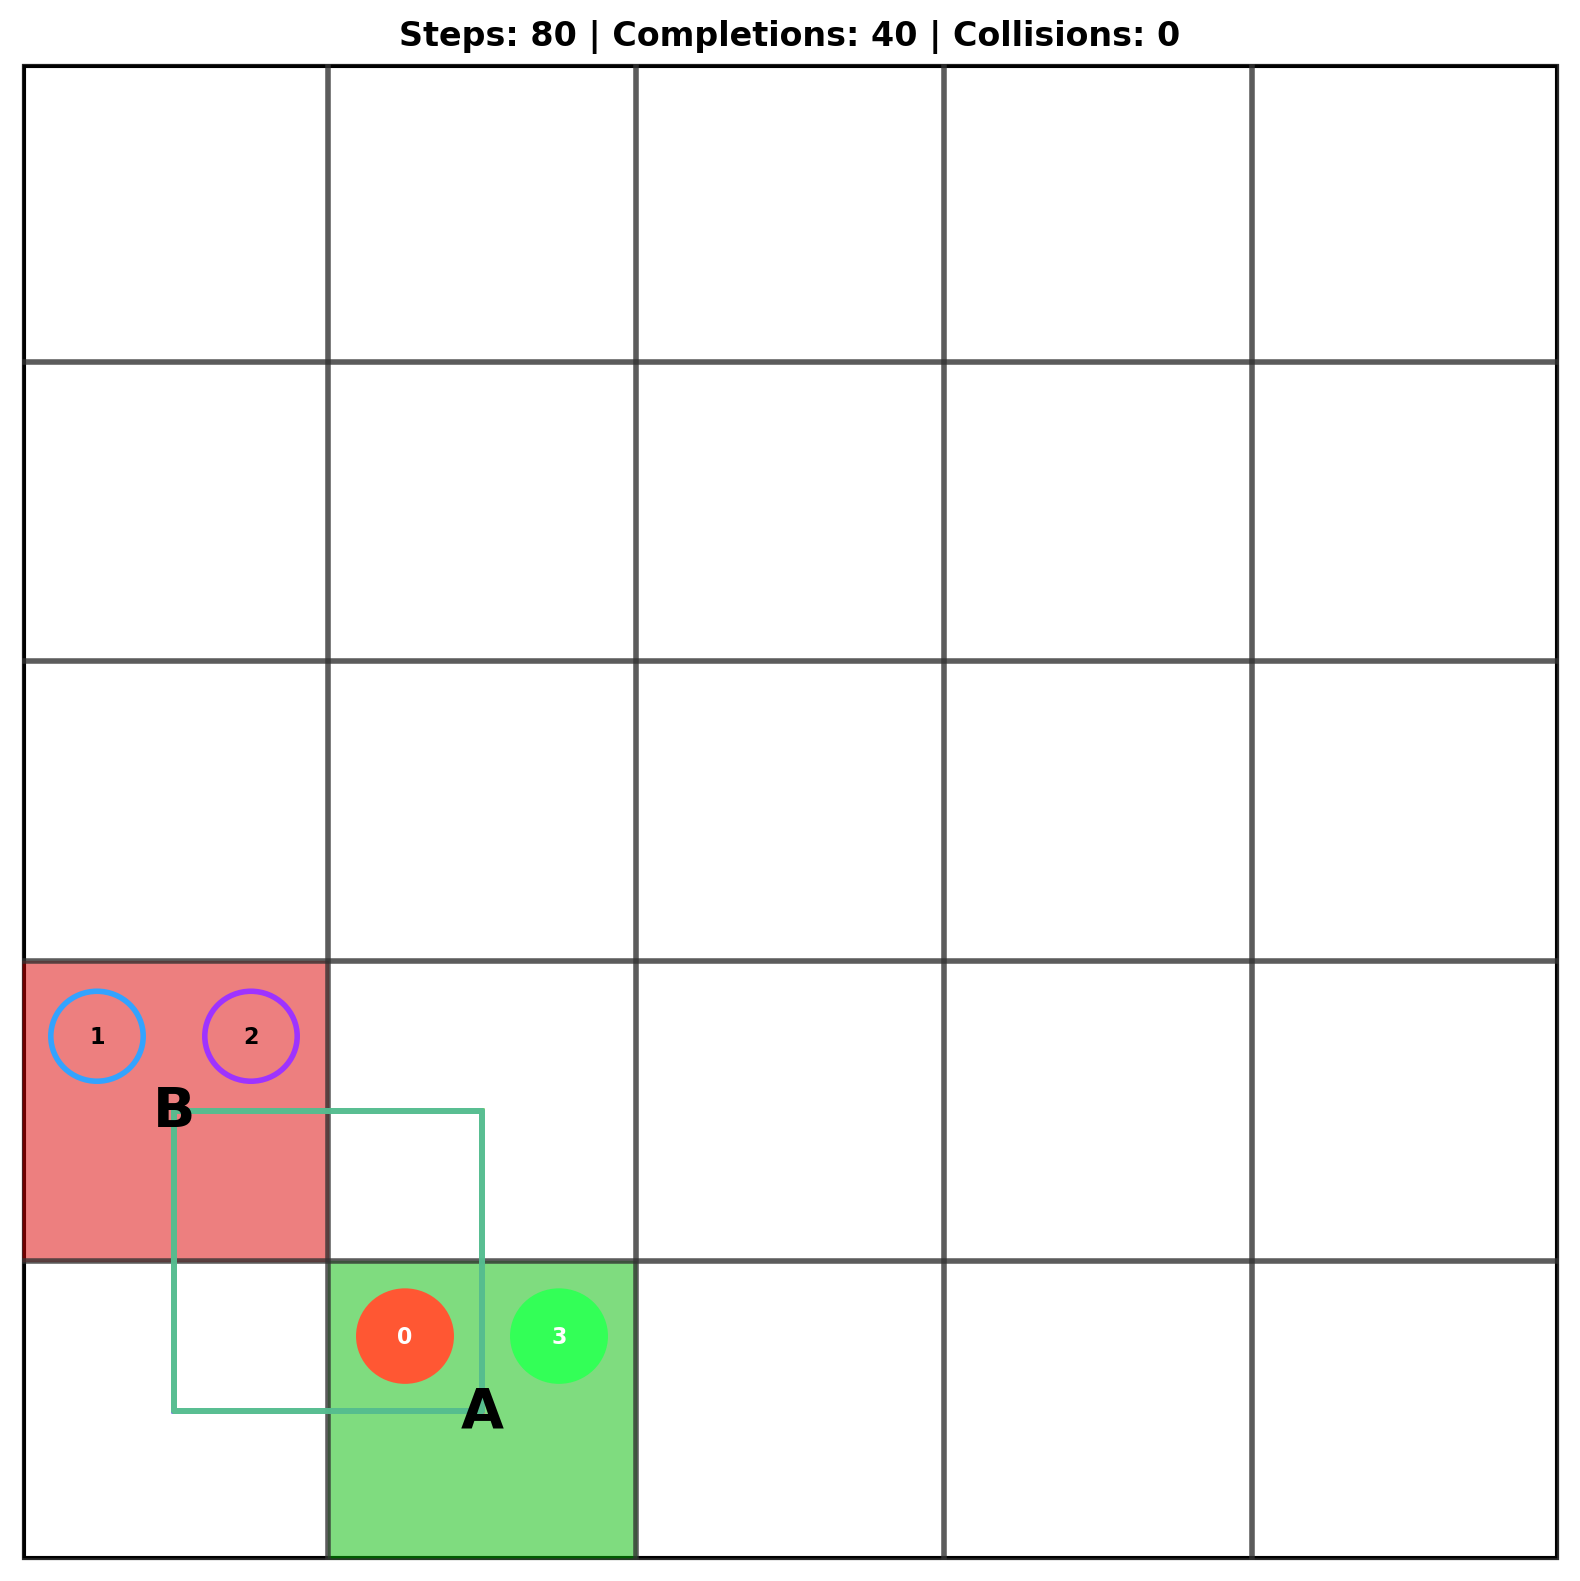


Simulation summary:
- Steps taken: 80
- Tasks completed: 40
- Collisions occurred: 0


(40, 0, 80)

In [79]:
visualize_agent(DQN_agent, steps=80, delay=0.1)